**Chapter 12 – Custom Models and Training with TensorFlow**

This chapter covers how to build custom models and training loops using TensorFlow. You'll learn how to create custom layers and models, implement custom training loops, and use TensorFlow's low-level APIs to have fine-grained control over the training process. Topics include using `tf.GradientTape` for computing gradients, creating custom loss functions, and handling different types of data structures that TensorFlow supports.


_This notebook contains all the sample code and solutions to the exercises in chapter 12, as well as code examples from Appendix C_

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

## Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

And TensorFlow ≥ 2.8:

In [2]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

## Using TensorFlow like NumPy
TensorFlow provides a NumPy-like API that allows you to perform operations on tensors in a way that is similar to how you would work with NumPy arrays. This makes it easier for developers who are familiar with NumPy to transition to using TensorFlow for machine learning tasks.

### Tensors and Operations
In TensorFlow, the primary data structure is the tensor, which is a multi-dimensional array. You can create tensors using `tf.constant`, `tf.Variable`, or by converting NumPy arrays to tensors using `tf.convert_to_tensor`. Once you have tensors, you can perform various operations on them, such as addition, multiplication, and more complex mathematical functions. For example:

#### Tensors
A **tensor** is TensorFlow’s core data structure: an n-dimensional array, similar to a NumPy array, but designed for efficient computation on CPUs, GPUs, and TPUs.

You can create tensors from Python values or NumPy arrays using functions like `tf.constant()`, then inspect their **shape** and **dtype**. TensorFlow supports familiar operations such as slicing, arithmetic, matrix multiplication, and many math transforms directly on tensors.

In [3]:
t = tf.constant([[1., 2., 3.], [4., 5., 6.]]) # matrix
t

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

The previous cell initializes a TensorFlow constant tensor `t` as a 2x3 matrix of `tf.float32` type. It then displays the tensor.

In [ ]:
t.shape

TensorShape([2, 3])

In [ ]:
t.dtype

tf.float32

It displays the data type of the tensor `t`, which is `tf.float32`. This indicates that the tensor stores floating-point numbers with 32-bit precision.

#### Indexing

In [6]:
t[:, 1:]

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [7]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

#### Ops

In [ ]:
t + 10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [9]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [10]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

#### Scalars
A **scalar** in TensorFlow is a tensor with a single value (rank 0), such as an integer, float, or string.  
You can create one with `tf.constant(42)`, and it behaves like a NumPy scalar while still supporting TensorFlow operations and automatic type/shape tracking.

In [11]:
tf.constant(42)

<tf.Tensor: shape=(), dtype=int32, numpy=42>

#### Keras's low-level API

You may still run across code that uses Keras's low-level API:

In [ ]:
K = tf.keras.backend
K.square(K.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

But since Keras does not support multiple backends anymore, you should instead use TF's low-level API directly:

In [13]:
tf.square(tf.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

### Tensors and NumPy
TensorFlow tensors can be easily converted to NumPy arrays using the `.numpy()` method, and NumPy arrays can be converted to TensorFlow tensors using `tf.convert_to_tensor()`. This interoperability allows you to leverage the strengths of both libraries in your machine learning workflows. For example:

In [ ]:
import numpy as np

a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [15]:
t.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [16]:
np.array(t)

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [17]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [18]:
np.square(t)

array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)

### Type Conversions
By default, TensorFlow will try to infer the data type of a tensor based on the input values. However, you can explicitly specify the data type using the `dtype` argument when creating a tensor. For example:

In [19]:
try:
    tf.constant(2.0) + tf.constant(40)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 


In [20]:
try:
    tf.constant(2.0) + tf.constant(40., dtype=tf.float64)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 


On the other hand, you can also convert a tensor to a different data type using the `tf.cast()` function.

In [21]:
t2 = tf.constant(40., dtype=tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

### Variables
A **variable** in TensorFlow is a mutable tensor used to store model parameters (such as weights and biases) or any state that must change during execution.

Unlike `tf.constant`, a `tf.Variable` can be updated in place with methods like `assign()`, `assign_add()`, and `assign_sub()`.  
This makes variables essential for training, where gradient-based optimizers repeatedly modify parameter values.

In [ ]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [23]:
v.assign(2 * v)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [24]:
v[0, 1].assign(42)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [25]:
v[:, 2].assign([0., 1.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

In [26]:
v.scatter_nd_update(
    indices=[[0, 0], [1, 2]], updates=[100., 200.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

In [ ]:
# extra code – shows how to use scatter_update()
sparse_delta = tf.IndexedSlices(values=[[1., 2., 3.], [4., 5., 6.]],
                                indices=[1, 0])
v.scatter_update(sparse_delta)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[4., 5., 6.],
       [1., 2., 3.]], dtype=float32)>

In [28]:
try:
    v[1] = [7., 8., 9.]
except TypeError as ex:
    print(ex)

'ResourceVariable' object does not support item assignment


In [29]:
v[1].assign([7., 8., 9.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[4., 5., 6.],
       [7., 8., 9.]], dtype=float32)>

To update part of a variable, use a variable-level update such as `scatter_nd_add` / `scatter_nd_sub` (or `tf.tensor_scatter_nd_add` returning a new tensor and then assign):

In [30]:
v = tf.Variable([[1., 2.], [3., 4.]])

# add 2 to v[0,0] and 3 to v[1,1]
v.scatter_nd_add(indices=[[0,0],[1,1]], updates=[2., 3.])

<tf.Variable 'UnreadVariable' shape=(2, 2) dtype=float32, numpy=
array([[3., 2.],
       [3., 7.]], dtype=float32)>

or

In [31]:
update = tf.tensor_scatter_nd_add(v, [[0,1]], [5.])
v.assign(update)

<tf.Variable 'UnreadVariable' shape=(2, 2) dtype=float32, numpy=
array([[3., 7.],
       [3., 7.]], dtype=float32)>

### Strings

The code in this section and all the following sections  in appendix C

In [32]:
tf.constant(b"hello world")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

`tf.constant(b"hello world")` creates a TensorFlow tensor whose value is the byte string `b"hello world"`. In TensorFlow, `tf.constant(...)` builds an immutable tensor from the given Python value; here the input is a Python bytes literal, so TensorFlow infers a tensor of type `tf.string` (TensorFlow’s dtype for raw bytes/UTF-8 strings). The resulting tensor has shape `()` (a scalar) because the input is a single item, and its value is the exact byte sequence provided.

In [33]:
tf.constant("café")

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

`tf.constant("café")` builds a TensorFlow scalar tensor whose value is the Unicode string `"café"`. TensorFlow represents strings as `tf.string` tensors (a byte‑string dtype that holds UTF‑8 encoded text), so the input is encoded as UTF‑8 and stored as a scalar tensor with shape `()`. The resulting tensor is immutable and behaves like any other TensorFlow tensor (it can participate in operations, be converted to NumPy, etc.), but it is not a Python string object.

It it noted that "café" is a Unicode string containing the character "é", which is encoded in UTF-8 as two bytes (`0xc3 0xa9`). When you create a TensorFlow string tensor from this Unicode string, TensorFlow encodes it as UTF-8 and stores the resulting byte sequence in a `tf.string` tensor. The resulting tensor will have the value `b"caf\xc3\xa9"` when viewed as bytes, but it will be displayed as `"café"` when printed, since TensorFlow decodes it back to Unicode for display purposes.

In [ ]:
u = tf.constant([ord(c) for c in "café"])
u

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

Here, `ord(c)` returns the Unicode code point of the character 'c', which is 99. The `tf.strings.unicode_decode()` function takes a string tensor and decodes it into a tensor of Unicode code points (integers). In this case, it decodes the string "café" into its corresponding Unicode code points, resulting in the tensor `[99, 97, 102, 233]`, where 99 corresponds to 'c', 97 to 'a', 102 to 'f', and 233 to 'é'.

In [35]:
b = tf.strings.unicode_encode(u, "UTF-8")
tf.strings.length(b, unit="UTF8_CHAR")

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [36]:
tf.strings.unicode_decode(b, "UTF-8")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

### Other Data Structures

The code in this section is in Appendix C.

#### String arrays

In [ ]:
tf.constant(b"hello world")

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

In [ ]:
tf.constant("café")

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [39]:
u = tf.constant([ord(c) for c in "café"])
u

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [40]:
b = tf.strings.unicode_encode(u, "UTF-8")
b

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [41]:
tf.strings.length(b, unit="UTF8_CHAR")

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [42]:
tf.strings.unicode_decode(b, "UTF-8")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [43]:
p = tf.constant(["Café", "Coffee", "caffè", "咖啡"])

In [44]:
tf.strings.length(p, unit="UTF8_CHAR")

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([4, 6, 5, 2], dtype=int32)>

In [45]:
r = tf.strings.unicode_decode(p, "UTF8")
r

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857]]>

#### Ragged tensors
Ragged tensors are tensors whose rows can have different lengths, making them ideal for representing variable-size data such as sentences, word-piece tokens, or sets of items per example. In TensorFlow, `tf.RaggedTensor` lets you slice, concatenate, and convert this irregular structure efficiently without padding everything to the same shape.

In [46]:
r[1]

<tf.Tensor: shape=(6,), dtype=int32, numpy=array([ 67, 111, 102, 102, 101, 101], dtype=int32)>

The result is a regular tf.Tensor because a single row of a ragged tensor has a fixed length.

In [47]:
r[1:3]  # extra code – a slice of a ragged tensor is a ragged tensor

<tf.RaggedTensor [[67, 111, 102, 102, 101, 101], [99, 97, 102, 102, 232]]>

Slices the ragged tensor from index 1 to 2. The result is a new `tf.RaggedTensor` containing only those rows.

Next, creates a new ragged tensor with 3 rows of lengths 2, 0, and 1 respectively. Besides, concatenates the original ragged tensor with the new one along the first axis (rows). The result is a new `tf.RaggedTensor` with 7 rows, where the first four rows are from the original tensor and the last three rows are from the new tensor.

In [48]:
r2 = tf.ragged.constant([[65, 66], [], [67]])
tf.concat([r, r2], axis=0)

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857], [65, 66], [], [67]]>

In [49]:
r3 = tf.ragged.constant([[68, 69, 70], [71], [], [72, 73]])
print(tf.concat([r, r3], axis=1))

<tf.RaggedTensor [[67, 97, 102, 233, 68, 69, 70], [67, 111, 102, 102, 101, 101, 71],
 [99, 97, 102, 102, 232], [21654, 21857, 72, 73]]>


In [50]:
r.to_tensor()

<tf.Tensor: shape=(4, 6), dtype=int32, numpy=
array([[   67,    97,   102,   233,     0,     0],
       [   67,   111,   102,   102,   101,   101],
       [   99,    97,   102,   102,   232,     0],
       [21654, 21857,     0,     0,     0,     0]], dtype=int32)>

`to_tensor()` converts a ragged tensor to a regular tensor by **padding** the shorter rows with a specified value (default is 0). This is useful when you need to perform operations that require uniform shapes, but it can lead to increased memory usage if there are many short rows.

#### Sparse tensors
A sparse tensor is a tensor that contains mostly zero values, and it is represented in a memory-efficient way by only storing the non-zero values and their indices. In TensorFlow, `tf.SparseTensor` allows you to work with sparse data without having to convert it to a dense format, which can save memory and computational resources when dealing with large datasets that have many zero entries.

In [51]:
s = tf.SparseTensor(indices=[[0, 1], [1, 0], [2, 3]],
                    values=[1., 2., 3.],
                    dense_shape=[3, 4])
s

SparseTensor(indices=tf.Tensor(
[[0 1]
 [1 0]
 [2 3]], shape=(3, 2), dtype=int64), values=tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

Converts a sparse tensor to a dense tensor, filling in the missing values with zeros. The resulting dense tensor has the same shape as the original sparse tensor, but all the zero values are explicitly represented.

In [52]:
tf.sparse.to_dense(s)

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 1., 0., 0.],
       [2., 0., 0., 0.],
       [0., 0., 0., 3.]], dtype=float32)>

In [53]:
s * 42.0

SparseTensor(indices=tf.Tensor(
[[0 1]
 [1 0]
 [2 3]], shape=(3, 2), dtype=int64), values=tf.Tensor([ 42.  84. 126.], shape=(3,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

In [54]:
try:
    s + 42.0
except TypeError as ex:
    print(ex)

unsupported operand type(s) for +: 'SparseTensor' and 'float'


In [55]:
# extra code – shows how to multiply a sparse tensor and a dense tensor
s4 = tf.constant([[10., 20.], [30., 40.], [50., 60.], [70., 80.]])
s4


<tf.Tensor: shape=(4, 2), dtype=float32, numpy=
array([[10., 20.],
       [30., 40.],
       [50., 60.],
       [70., 80.]], dtype=float32)>

In [56]:
tf.sparse.sparse_dense_matmul(s, s4)

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 30.,  40.],
       [ 20.,  40.],
       [210., 240.]], dtype=float32)>

In [57]:
# extra code – when creating a sparse tensor, values must be given in "reading
#              order", or else `to_dense()` will fail.
s5 = tf.SparseTensor(indices=[[0, 2], [0, 1]],  # WRONG ORDER!
                     values=[1., 2.],
                     dense_shape=[3, 4])
try:
    tf.sparse.to_dense(s5)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

{{function_node __wrapped__SparseToDense_device_/job:localhost/replica:0/task:0/device:CPU:0}} indices[1] = [0,1] is out of order. Many sparse ops require sorted indices.
    Use `tf.sparse.reorder` to create a correctly ordered copy.

 [Op:SparseToDense] name: 


In [58]:
s5

SparseTensor(indices=tf.Tensor(
[[0 2]
 [0 1]], shape=(2, 2), dtype=int64), values=tf.Tensor([1. 2.], shape=(2,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

In [59]:
# extra code – shows how to fix the sparse tensor s5 by reordering its values
s6 = tf.sparse.reorder(s5)
s6

SparseTensor(indices=tf.Tensor(
[[0 1]
 [0 2]], shape=(2, 2), dtype=int64), values=tf.Tensor([2. 1.], shape=(2,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

In [60]:
tf.sparse.to_dense(s6)

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 2., 1., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

#### Tensor Arrays
A `TensorArray` is a data structure in TensorFlow that allows you to store and manipulate **a list of tensors**. It is particularly useful for dynamic computations, such as loops or variable-length sequences, where the number of tensors may not be known in advance. TensorArrays provide efficient methods for writing to and reading from the array, as well as for stacking and unstacking tensors.

In [61]:
# instantiating a TensorArray with data type float32 and size 3
array = tf.TensorArray(dtype=tf.float32, size=3)

# writing values to the TensorArray at specific indices
array = array.write(0, tf.constant([1., 2.]))
array = array.write(1, tf.constant([3., 10.]))
array = array.write(2, tf.constant([5., 7.]))

# reading a value from the TensorArray at a specific index (this also zeros out the value at that index)
tensor1 = array.read(1)  # returns (and zeros out!) tf.constant([3., 10.])

- The array is typed: every element stored in it must be a float32 tensor.
- The size is fixed at 3, so it can hold exactly three tensors (though `TensorArray` can also be created with `size=0` and then grown later if needed).

A `TensorArray` is useful when you need to build or manipulate a sequence of tensors inside a `tf.while_loop` or other graph-based control flow, because it provides safe, efficient read/write semantics and can be stacked/emitted later as a single tensor.

In [62]:
tensor1

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([ 3., 10.], dtype=float32)>

In [63]:
array

In [64]:
array.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

`clear_after_read` is a parameter of `TensorArray` that determines whether the elements of the array should be cleared (set to zero) after they have been read.
- `True`: then once an element is read from the `TensorArray`, it will be cleared, which can help save memory if the elements are no longer needed after being read.
- `False`: the elements will remain unchanged after being read, allowing you to read them multiple times if necessary.

In [65]:
# extra code – shows how to disable clear_after_read
array2 = tf.TensorArray(dtype=tf.float32, size=3, clear_after_read=False)
array2 = array2.write(0, tf.constant([1., 2.]))
array2 = array2.write(1, tf.constant([3., 10.]))
array2 = array2.write(2, tf.constant([5., 7.]))
tensor2 = array2.read(1)  # returns tf.constant([3., 10.])
array2.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 1.,  2.],
       [ 3., 10.],
       [ 5.,  7.]], dtype=float32)>

In [66]:
tensor2

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([ 3., 10.], dtype=float32)>

Moreover, `dynamic_size` is a parameter of `TensorArray` that indicates whether the size of the array can change dynamically during execution.
- If `dynamic_size` is set to `True`, you can write to indices that are beyond the current size of the array, and the array will automatically resize itself to accommodate the new indices.
- If it is set to `False`, you must specify a fixed size for the array when it is created, and you cannot write to indices that exceed this size.
> This parameter allows for flexibility in handling sequences of varying lengths or when the number of elements is not known in advance.

In [67]:
# extra code – shows how to create and use a tensor array with a dynamic size
array3 = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)
array3 = array3.write(0, tf.constant([1., 2.]))
array3 = array3.write(1, tf.constant([3., 10.]))
array3 = array3.write(2, tf.constant([5., 7.]))
tensor3 = array3.read(1)
array3.stack()

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

In [68]:
array3 = array3.write(5, tf.constant([11., 13.]))
array3.stack()

<tf.Tensor: shape=(6, 2), dtype=float32, numpy=
array([[ 1.,  2.],
       [ 0.,  0.],
       [ 5.,  7.],
       [ 0.,  0.],
       [ 0.,  0.],
       [11., 13.]], dtype=float32)>

`array3 = array3.write(5, tf.constant([11., 13.]))` writes the 1D tensor `[11., 13.]` to index `5` of `array3`.

Because `array3` was created with `dynamic_size=True`, writing past the current highest index is allowed, so the TensorArray grows to size `6` (indices `0` through `5`).

`array3.stack()` then attempts to combine all elements into one tensor along axis `0`.

For `stack()` to work, every index from `0` to `size - 1` must be written.  
If some indices are missing (here, `3` and `4`), TensorFlow raises an error about unwritten elements.

In [69]:
array3 = array3.write(1, tf.constant([1, 5], dtype=tf.float32))
array3.write(4, tf.constant([9,99], dtype=tf.float32)).mark_used()  # mark_used() is needed to prevent an error about writing to an index that has already been read
array3.stack()

<tf.Tensor: shape=(6, 2), dtype=float32, numpy=
array([[ 1.,  2.],
       [ 1.,  5.],
       [ 5.,  7.],
       [ 0.,  0.],
       [ 9., 99.],
       [11., 13.]], dtype=float32)>

#### Sets
A set is a collection of unique elements, and in TensorFlow, you can use `tf.sets` to perform set operations such as union, intersection, and difference on tensors. This is useful for tasks like finding unique values, comparing sets of items, or performing operations on categorical data. For example:

In [70]:
a = tf.constant([[1, 5, 9]])
b = tf.constant([[5, 6, 9, 11]])
u = tf.sets.union(a, b)
u

SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]], shape=(5, 2), dtype=int64), values=tf.Tensor([ 1  5  6  9 11], shape=(5,), dtype=int32), dense_shape=tf.Tensor([1 5], shape=(2,), dtype=int64))

- `a` and `b` are 2D integer tensors (shape `(1, n)`) representing one set per row.
- `tf.sets.union(a, b)` computes the **set union** row by row:
    - keeps unique values,
    - includes values present in either `a` or `b`.
- So for this row, the union is `{1, 5, 6, 9, 11}`.
- The result `u` is returned as a **SparseTensor** (TensorFlow uses sparse format for set ops).

Thus, we can use `tf.sparse.to_dense(u)` to convert the sparse tensor `u` into a dense tensor, which will contain the unique values from both `a` and `b` in a regular 2D tensor format. The resulting dense tensor will have the same shape as the original input tensors, but with the unique values filled in and any missing values (if any) set to zero.

In [ ]:
tf.sparse.to_dense(u)

<tf.Tensor: shape=(1, 5), dtype=int32, numpy=array([[ 1,  5,  6,  9, 11]], dtype=int32)>

In [72]:
a = tf.constant([[1, 5, 9], [10, 0, 0]])
b = tf.constant([[5, 6, 9, 11], [13, 0, 0, 0]])
u = tf.sets.union(a, b)
tf.sparse.to_dense(u)

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [ 0, 10, 13,  0,  0]], dtype=int32)>

In [73]:
# extra code – shows how to use a different default value: -1 in this case
a = tf.constant([[1, 5, 9], [10, -1, -1]])
b = tf.constant([[5, 6, 9, 11], [13, -1, -1, -1]])
u = tf.sets.union(a, b)
tf.sparse.to_dense(u, default_value=-1)

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [-1, 10, 13, -1, -1]], dtype=int32)>

`tf.sets.difference(a, b)` computes the set difference of `a` and `b` row by row, returning the unique values that are present in `a` but not in `b`. The result is also returned as a SparseTensor.

In [74]:
# extra code – shows how to use `tf.sets.difference()`
set1 = tf.constant([[2, 3, 5, 7], [7, 9, 0, 0]])
set2 = tf.constant([[4, 5, 6], [9, 10, 0]])
tf.sparse.to_dense(tf.sets.difference(set1, set2))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[2, 3, 7],
       [7, 0, 0]], dtype=int32)>

`tf.sets.intersection(set1, set2)` computes the set intersection of `set1` and `set2` row by row, returning the unique values that are present in both sets. The result is returned as a SparseTensor.

In [75]:
# extra code – shows how to use `tf.sets.intersection()`
tf.sparse.to_dense(tf.sets.intersection(set1, set2))

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[5, 0],
       [0, 9]], dtype=int32)>

In [76]:
# extra code – check whether set1[0] contains 5
tf.sets.size(tf.sets.intersection(set1[:1], tf.constant([[5, 0, 0, 0]]))) > 0

<tf.Tensor: shape=(1,), dtype=bool, numpy=array([ True])>

#### Queues
In TensorFlow, **queues** are stateful data structures used to hold tensors and process them in FIFO/LIFO order, mainly for input pipelines and asynchronous producer–consumer workflows.

Most queue-based APIs (e.g., `tf.queue.FIFOQueue`) are **legacy** from TensorFlow 1.x.  
In modern TensorFlow, you should generally use the **`tf.data` API** instead, which is simpler, more scalable, and integrates better with eager execution and Keras training loops.

In [77]:
# q is a FIFO queue that can hold up to 3 elements, where each element is a tuple of an integer and a string. The shapes argument specifies that the integer and string are scalar values (i.e., they have no dimensions).
q = tf.queue.FIFOQueue(3, [tf.int32, tf.string], shapes=[(), ()])

# enqueue two elements into the queue: the first element is a tuple of the integer 10 and the byte string "windy", and the second element is a tuple of the integer 15 and the byte string "sunny".
q.enqueue([10, b"windy"])
q.enqueue([15, b"sunny"])

# get the current size of the queue
q.size()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [78]:
q

`.dequeue()` removes and returns the front element of the queue, following the FIFO (First-In-First-Out) principle. If the queue is empty, it will block until an element is available.

In [ ]:
q.dequeue()

[<tf.Tensor: shape=(), dtype=int32, numpy=10>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'windy'>]

`enqueue_many()` allows you to enqueue multiple elements into the queue at once. You can pass a list of tensors (or a single tensor with an extra dimension) to this method, and it will add all of them to the queue in the order they are provided. This is more efficient than calling `enqueue()` multiple times for each element.

In [80]:
q.enqueue_many([[13, 16], [b'cloudy', b'rainy']])

In [81]:
q.dequeue_many(3)

[<tf.Tensor: shape=(3,), dtype=int32, numpy=array([15, 13, 16], dtype=int32)>,
 <tf.Tensor: shape=(3,), dtype=string, numpy=array([b'sunny', b'cloudy', b'rainy'], dtype=object)>]

In [82]:
try:
    q.enqueue_many([[17, b'sunny'], [20, b'windy']])
except ValueError as err:
    print(err)
    q.enqueue_many([[17, 20], [b'sunny', b'windy']])

Can't convert Python sequence with mixed types to Tensor.


In this snippet you’re calling `q.enqueue_many(...)` on a `tf.queue.FIFOQueue` that was created to hold **tuples** of `(int32, string)` values.

`enqueue_many()` expects one tensor per queue component (i.e., one tensor for all the integers, one tensor for all the strings), so it can push multiple elements in a single call. When you pass a plain Python list, TensorFlow tries to convert it to a single tensor first, and that conversion requires a **uniform dtype**.

Here you passed:

- `[[17, b'sunny'], [20, b'windy']]`  

That’s a list-of-rows (mixed int/bytes inside each inner list), so TensorFlow tries to build a single tensor with mixed types and fails with:

> “Can’t convert Python sequence with mixed types to Tensor.”

To make `enqueue_many()` work, you need to pass it one sequence per queue slot, e.g.:

- integers: `[17, 20]`
- strings: `[b"sunny", b"windy"]`

That matches the queue’s declared dtypes and avoids the “mixed types” conversion error.

In [83]:
q.dequeue_many(2)

[<tf.Tensor: shape=(2,), dtype=int32, numpy=array([17, 20], dtype=int32)>,
 <tf.Tensor: shape=(2,), dtype=string, numpy=array([b'sunny', b'windy'], dtype=object)>]

---

## Custom loss function
A custom loss function in TensorFlow is a user-defined function that computes the loss (or error) between the predicted outputs of a model and the true labels. This allows you to define your own criteria for how well the model is performing, which can be particularly useful when the standard loss functions provided by TensorFlow do not fit your specific problem or when you want to incorporate additional factors into the loss calculation. Custom loss functions can be used in Keras models by passing them to the `compile()` method, and they can also be used in custom training loops with `tf.GradientTape` for more control over the training process.

First, you define a custom loss function. For example, the Huber loss function:

In [84]:
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss  = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

This `huber_fn(y_true, y_pred)` implements the **Huber loss** with `delta = 1.0`. It computes the error `e = y_true - y_pred` and then:
- uses a **quadratic** term (`e² / 2`) when `|e| < 1`, and
- switches to a **linear** term (`|e| - 0.5`) when `|e| ≥ 1`.

This makes the loss **less sensitive to large outliers** than mean squared error while still being smooth near zero. You can use this custom loss in Keras by passing it to `model.compile(loss=huber_fn, ...)`, or inside a custom training loop with `tf.GradientTape` for more control over the training process.

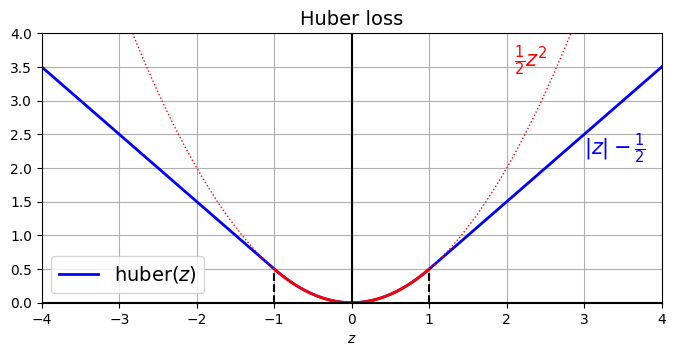

In [85]:
# extra code – shows what the Huber loss looks like

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 3.5))
z = np.linspace(-4, 4, 200)
z_center = np.linspace(-1, 1, 200)
plt.plot(z, huber_fn(0, z), "b-", linewidth=2, label="huber($z$)")
plt.plot(z, z ** 2 / 2, "r:", linewidth=1)
plt.plot(z_center, z_center ** 2 / 2, "r", linewidth=2)
plt.plot([-1, -1], [0, huber_fn(0., -1.)], "k--")
plt.plot([1, 1], [0, huber_fn(0., 1.)], "k--")
plt.gca().axhline(y=0, color='k')
plt.gca().axvline(x=0, color='k')
plt.text(2.1, 3.5, r"$\frac{1}{2}z^2$", color="r", fontsize=15)
plt.text(3.0, 2.2, r"$|z| - \frac{1}{2}$", color="b", fontsize=15)
plt.axis([-4, 4, 0, 4])
plt.grid(True)
plt.xlabel("$z$")
plt.legend(fontsize=14)
plt.title("Huber loss", fontsize=14)
plt.show()

### Load the California housing dataset
To test our custom loss function, let's create a basic Keras model and train it on the California housing dataset:

In [86]:
# extra code – loads, splits and scales the California housing dataset, then
#              creates a simple Keras model

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
housing


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [87]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

In [88]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

input_shape = X_train.shape[1:]


In [ ]:

tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
])

Here, we create a simple feedforward neural network with one hidden layer of 30 neurons and ReLU activation. We compile the model using our custom `huber_fn` as the loss function, `loss=huber_fn`, and the Nadam optimizer. Finally, we fit the model to the training data for 2 epochs.

In [90]:
model.compile(loss=huber_fn, optimizer="nadam", metrics=["mae"])

In [91]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4838 - mae: 0.8334 - val_loss: 0.3474 - val_mae: 0.6522
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2404 - mae: 0.5406 - val_loss: 0.2553 - val_mae: 0.5383


The output shown is the standard Keras progress display:
- It prints epoch progress (Epoch 1/2, Epoch 2/2).
- For each epoch it reports the training loss and MAE, and the validation loss and MAE at the end of the epoch.
- The numbers indicate the model is improving: training loss/MAE and validation loss/MAE both decrease from epoch 1 to epoch 2.

---

## Saving/Loading Models with Custom Objects
When you save a Keras model that includes custom objects (such as custom layers, loss functions, or metrics), you need to ensure that these custom components are properly handled during the saving and loading process. Keras provides a way to specify custom objects when loading a model, so that it can correctly reconstruct the model architecture and functionality.

In [92]:
model.save("my_model_with_a_custom_loss.keras")  # extra code – saving works fine

When loading a Keras model that uses custom objects (such as our `huber_fn` loss), you must pass a `custom_objects` dictionary to `tf.keras.models.load_model()`. This tells Keras how to reconstruct the custom components by mapping their names to the actual Python objects:
- The **key** (`"huber_fn"`) must match the name Keras stored in the model config (i.e., the function's `__name__`).
- The **value** (`huber_fn`) is the actual Python callable that Keras will use to reconstruct the loss.

Without `custom_objects`, Keras would raise a `ValueError` because it cannot find `huber_fn` in its built-in registry.

In [93]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss.keras",
                                   custom_objects={"huber_fn": huber_fn})

In [94]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2065 - mae: 0.4930 - val_loss: 0.2129 - val_mae: 0.4876
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1904 - mae: 0.4700 - val_loss: 0.1891 - val_mae: 0.4610


Besides, a factory function can be used to create a custom loss with specific parameters, and you can also save/load it using `custom_objects`:

In [95]:
def create_huber(threshold=1.0):
    """Factory function that creates a Huber loss function with a custom threshold.

    Args:
        threshold: The threshold value for the Huber loss. For errors below this
                   threshold, quadratic loss is used; above it, linear loss is used.
                   Default is 1.0.

    Returns:
        A huber_fn function that computes the Huber loss with the specified threshold.
    """

    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = threshold * tf.abs(error) - threshold ** 2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

The Huber loss function is defined as:

$$
L_{\delta}(y_{true}, y_{pred}) =
\begin{cases}
\frac{1}{2}(y_{true} - y_{pred})^2 & \text{if } |y_{true} - y_{pred}| \le \delta \\
\delta(|y_{true} - y_{pred}| - \frac{1}{2}\delta) & \text{if } |y_{true} - y_{pred}| > \delta
\end{cases}
$$

`create_huber(threshold=1.0)` is a **loss factory**: it builds and returns a custom Huber loss function with a chosen cutoff (`threshold`).
- It defines an inner function `huber_fn(y_true, y_pred)`.
- $error = y_{true} - y_{pred}$
- If $|error| \le threshold$, it uses quadratic loss: $\frac{1}{2} error^2$
- Otherwise, it uses linear loss: $threshold \times |error| - \frac{1}{2} threshold^2$

This makes training less sensitive to outliers than MSE, while staying smooth near zero.

Because `huber_fn` closes over `threshold`, you can create different loss behaviors:
- `create_huber(threshold=1.0)` creates a standard Huber loss with a cutoff of 1.0.
- `create_huber(threshold=2.0)` creates a Huber loss that is less sensitive to outliers, with a cutoff of 2.0.


In [96]:
model.compile(loss=create_huber(2.0), optimizer="nadam", metrics=["mae"])

In [97]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2060 - mae: 0.4611 - val_loss: 0.2084 - val_mae: 0.4504
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1979 - mae: 0.4529 - val_loss: 0.1807 - val_mae: 0.4340


In [98]:
model.save("my_model_with_a_custom_loss_threshold_2.keras")

In [99]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_threshold_2.keras",
                                   custom_objects={"huber_fn": create_huber(2.0)})

It is noted that by setting `custom_objects={"huber_fn": create_huber(threshold=2.0)}`, you can load a model that uses a custom Huber loss with a cutoff of 2.0, allowing you to maintain the same loss behavior when saving and loading the model.

In [100]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1927 - mae: 0.4468 - val_loss: 0.1853 - val_mae: 0.4339
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1887 - mae: 0.4414 - val_loss: 0.1976 - val_mae: 0.4367


Moreover, you can also customize a class-based loss function with specific parameters, and save/load it using `custom_objects` as well. For example:

In [ ]:
class HuberLoss(tf.keras.losses.Loss):
    """ A custom Huber loss function that can be used in Keras models. The Huber loss is a robust loss function that is less sensitive to outliers than the mean squared error loss. It behaves like the mean squared error for small errors and like the mean absolute error for large errors, with a threshold parameter that determines the cutoff between the two behaviors.
    Arguments:
        threshold: A float value that determines the cutoff between the squared loss and linear loss behaviors.
    Returns:
        A tensor representing the Huber loss.
    """
    def __init__(self, threshold=1.0, **kwargs):
        """ Initializes the HuberLoss with a given threshold."""
        self.threshold = threshold
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """Computes the Huber loss between `y_true` and `y_pred`."""
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)

    def get_config(self):
        """Returns the configuration of the HuberLoss."""
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

This defines a **custom Keras loss class** called `HuberLoss` by subclassing `tf.keras.losses.Loss`.

- `__init__(self, threshold=1.0, **kwargs)`  
    Stores the Huber transition point (`threshold`) and forwards standard Keras loss arguments to the base class.

- `call(self, y_true, y_pred)`  
    Computes element-wise Huber loss:
    - `error = y_true - y_pred`
    - if `|error| < threshold`: uses quadratic loss `0.5 * error²`
    - otherwise: uses linear loss `threshold * |error| - threshold² / 2`  
    This makes training robust to outliers while remaining smooth near zero.

- `get_config(self)`  
    Returns the base config plus `threshold`, so the loss can be **serialized/deserialized** when saving and loading models.

This class-based approach is preferred when the loss has parameters and must be saved with full configuration.

In [102]:
# extra code – creates another basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
])

Here, we specify `loss=HuberLoss(threshold=2.0)` when compiling the model, which creates an instance of the `HuberLoss` class with a threshold of 2.0. This means that during training, the model will use this custom Huber loss function to compute the loss between the predicted outputs and the true labels, allowing for a specific sensitivity to outliers based on the chosen threshold.

In [103]:
model.compile(loss=HuberLoss(2.), optimizer="nadam", metrics=["mae"])

In [104]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6461 - mae: 0.8446 - val_loss: 0.5086 - val_mae: 0.6718
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2899 - mae: 0.5544 - val_loss: 0.3527 - val_mae: 0.5571


In [105]:
model.save("my_model_with_a_custom_loss_class.keras")  # extra code – saving works

In [106]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_class.keras",
                                   custom_objects={"HuberLoss": HuberLoss})

In [107]:
# extra code – shows that loading worked fine, the model can be used normally
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2444 - mae: 0.5073 - val_loss: 0.2689 - val_mae: 0.4982
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2213 - mae: 0.4818 - val_loss: 0.2207 - val_mae: 0.4657


In [108]:
model.loss.threshold  # extra code – the treshold was loaded correctly

2.0

---
## Other Custom Functions
Besides custom losses, Keras also supports many other custom functions, such as custom activation functions, initializers, regularizers, constraints, and metrics. These are useful when built-in options do not match your needs.

The key idea is the same: define your custom object, use it in the model, and ensure it can be serialized so models can be saved and loaded reliably. In the next examples, we create and use several of these custom functions.

In [109]:
def my_softplus(z):
    """ A custom softplus activation function that can be used in Keras models. The softplus function is a smooth approximation of the ReLU function, defined as `softplus(z) = log(1 + exp(z))`. It is often used as an activation function in neural networks to introduce non-linearity while avoiding the "dying ReLU" problem."""
    return tf.math.log(1.0 + tf.exp(z))

def my_glorot_initializer(shape, dtype=tf.float32):
    """Initializes weights with the Glorot (Xavier) normal distribution.

    This initializer keeps activation variance more stable across layers to help
    reduce vanishing/exploding gradients.

    Args:
        shape: Shape of the weight tensor to initialize.
        dtype: Data type of the returned tensor. Defaults to ``tf.float32``.

    Returns:
        A tensor of shape ``shape`` sampled from a normal distribution with
        Glorot-scaled standard deviation.
    """
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

def my_l1_regularizer(weights):
    """ A custom L1 regularizer function that can be used in Keras models. L1 regularization adds a penalty proportional to the absolute value of the weights to the loss function, encouraging sparsity in the model parameters."""
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights):  # return value is just tf.nn.relu(weights)
    """ A custom constraint function that ensures the weights of a layer remain positive during training."""
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

In [110]:
layer = tf.keras.layers.Dense(1, activation=my_softplus,
                              kernel_initializer=my_glorot_initializer,
                              kernel_regularizer=my_l1_regularizer,
                              kernel_constraint=my_positive_weights)

where
- `my_glorot_initializer` is a custom initializer function that implements the Glorot (Xavier) initialization strategy, which initializes weights in a way that maintains a consistent variance across layers, helping to prevent vanishing/exploding gradients during training. It calculates the limit for uniform distribution based on the number of input and output units and returns a tensor of initialized weights.
- `my_l1_regularizer` is a custom regularizer function that implements L1 regularization, which adds a penalty proportional to the absolute value of the weights to the loss function. This encourages sparsity in the model parameters, helping to prevent overfitting by driving some weights to zero.
- `my_positive_weights` is a custom constraint function that ensures that the weights of a layer remain positive during training. It does this by applying the ReLU function to the weights, which sets any negative values to zero. This can be useful in certain types of models where negative weights are not meaningful or desired.

In [ ]:
class MyL1Regularizer(tf.keras.regularizers.Regularizer):
    """Custom L1 regularizer that adds a penalty proportional to the absolute value of weights.

    Args:
        factor (float): The regularization multiplier.

    Returns:
        A tensor representing the L1 regularization penalty.
    """
    def __init__(self, factor: float):
        """Initializes the MyL1Regularizer with a given factor.
        Args:
            factor (float): The regularization multiplier.
        """
        super().__init__()
        self.factor = factor

    def __call__(self, weights: tf.Tensor) -> tf.Tensor:
        """Computes the L1 regularization penalty.
        Args:
            weights (tf.Tensor): The weights to regularize.
        Returns:
            tf.Tensor: The L1 regularization penalty.
        """
        return tf.reduce_sum(tf.abs(self.factor * weights))

    def get_config(self) -> dict:
        """Returns the configuration for serialization.
        Returns:
            dict: The configuration dictionary.
        """
        base_config = super().get_config()
        return {**base_config, "factor": self.factor}

#### `tf.reduce_sum()`
`tf.reduce_sum()` is a TensorFlow operation used to compute the sum of elements across specific dimensions of a tensor.

- **Axis Reduction**: It collapses the specified axes by adding up all values along them.
    - If `axis=None` (default), it sums **all** elements in the tensor, returning a scalar.
    - If an `axis` is specified, it sums along that dimension, resulting in a tensor with a reduced rank.
- **`keepdims` Parameter**:
    - `False` (default): The reduced dimensions are removed from the output shape.
    - `True`: The reduced axes are retained with a length of 1, which is helpful for maintaining the original rank for broadcasting.
- **Dtype Preservation**: Unlike NumPy’s `sum` (which may upcast types), `tf.reduce_sum()` preserves the input data type.

In the `MyL1Regularizer` example above, it is used to calculate the total penalty by summing the absolute values of the weights.

In [112]:
import tensorflow as tf
from typing import Any

class MyLInfinityRegularizer(tf.keras.regularizers.Regularizer):
    """Custom L-infinity regularizer that adds a penalty proportional to the
    maximum absolute value of weights.

    Args:
        factor (float): The regularization multiplier.

    Returns:
        A tensor representing the L-infinity regularization penalty.
    """
    def __init__(self, factor: float):
        """Initializes the MyLInfinityRegularizer with a given factor.
        Args:
            factor (float): The regularization multiplier.
        """
        super().__init__()
        self.factor = factor

    def __call__(self, weights: tf.Tensor) -> tf.Tensor:
        """Computes the L-infinity regularization penalty.
        Args:
            weights (tf.Tensor): The weights to regularize.
        Returns:
            tf.Tensor: The L-infinity regularization penalty.
        """
        # The L-infinity norm is the maximum absolute value of the weights
        return self.factor * tf.reduce_max(tf.abs(weights))

    def get_config(self) -> dict[str, Any]:
        """Returns the configuration for serialization.
        Returns:
            dict: The configuration dictionary.
        """
        # base_config = super().get_config()
        # return {**base_config, "factor": self.factor}

        # Only return the specific parameters of *this* class.
        # No need to call super().get_config() because the base class has nothing to contribute.

        return {"factor": self.factor}

    @classmethod
    def from_config(cls, config: dict[str, Any]):
        """Creates a regularizer instance from its configuration.
        This is used for deserialization when loading the model.

        Args:
            config: A dictionary containing the regularizer's configuration.

        Returns:
            A new instance of the MyLInfinityRegularizer.
        """
        return cls(**config)


In [113]:
tf.keras.utils.set_random_seed(42)

model_linf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=MyLInfinityRegularizer(factor=0.01)), # Using the custom L-infinity regularizer
    tf.keras.layers.Dense(1, kernel_regularizer=MyLInfinityRegularizer(factor=0.01))
])

model_linf.compile(loss="mse", optimizer="nadam")
model_linf.fit(X_train_scaled, y_train, epochs=2,
               validation_data=(X_valid_scaled, y_valid))

# To save and load the model with the custom regularizer
model_linf.save("my_model_with_linf_regularizer.keras")
loaded_model_linf = tf.keras.models.load_model(
    "my_model_with_linf_regularizer.keras",
    custom_objects={"MyLInfinityRegularizer": MyLInfinityRegularizer}
)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7550 - val_loss: 21.3148
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7856 - val_loss: 11.1657


In [114]:
loaded_model_linf.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 605 (2.37 KB)

---
## Custom Metrics

A **custom metric** in TensorFlow is a user-defined way to **measure model performance** during training/evaluation, beyond built-ins like accuracy or MAE.

Use a custom metric when you need a domain-specific score (for example, tolerance-based accuracy, weighted error, or business KPIs).

### Two common approaches

1. **Function metric (stateless)**
    - Simple to write.
    - Best when the metric can be computed directly from `y_true` and `y_pred` for each batch.

2. **Class metric (`tf.keras.metrics.Metric`, stateful)**
    - Recommended for metrics that must accumulate values across batches.
    - You define internal state variables and implement:
      - `update_state(...)`: updates the metric state with new batch data.
      - `result()`: computes and returns the final metric value.
      - `reset_state()`: resets all of the metric state variables.

### How to use in Keras

Pass your metric to `model.compile(...)`:

- As a function: `metrics=[my_metric_fn]`
- As a class instance: `metrics=[MyMetric(...)]`

Keras will automatically compute and display it during `fit()`, `evaluate()`, and logging.

### Practical note

If a custom metric class has *parameters*, implement `get_config()` so the model can be saved/loaded reliably with custom objects.

In [115]:
# extra code – once again, lets' create a basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
])

In [116]:
model.compile(loss="mse", optimizer="nadam", metrics=[create_huber(2.0)])

where the metric function `create_huber(2.0)` creates a custom Huber loss function with a threshold of 2.0 and it is passed to the model's `compile()` method as a custom metric. This allows the model to compute and report this custom Huber loss during training and evaluation, providing insights into the model's performance based on this specific metric.

In [117]:
# extra code – train the model with our custom metric
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - huber_fn: 0.6814 - loss: 1.7395
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - huber_fn: 0.3131 - loss: 0.7699


**Note**: if you use the same function as the loss and a metric, you may be surprised to see slightly different results. This is in part because the operations are not computed exactly in the same order, so there might be tiny floating point errors. More importantly, if you use sample weights or class weights, then the equations are a bit different:
* the `fit()` method keeps track of the mean of all batch losses seen so far since the start of the epoch. Each batch loss is the sum of the weighted instance losses divided by the _batch size_ (not the sum of weights, so the batch loss is _not_ the weighted mean of the losses).
* the metric since the start of the epoch is equal to the sum of weighted instance losses divided by sum of all weights seen so far. In other words, it is the weighted mean of all the instance losses. Not the same thing.

In [118]:
# extra code – once again, lets' create a basic Keras model
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
])

# use the same function as the loss and the metric, just to show that it works fine as a metric as well
model.compile(loss=create_huber(2.0), optimizer="nadam", metrics=[create_huber(2.0)])

model.fit(X_train_scaled, y_train, epochs=2, validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - huber_fn: 0.6461 - loss: 0.6461 - val_huber_fn: 0.5086 - val_loss: 0.5086
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - huber_fn: 0.2899 - loss: 0.2899 - val_huber_fn: 0.3527 - val_loss: 0.3527


### Streaming metrics

A **streaming metric** is a metric that updates its value **batch by batch** instead of recomputing everything from scratch on the full dataset.

This is useful when training or evaluating a model on large datasets, because TensorFlow does **not** need to keep all predictions and labels in memory. Instead, it keeps a small internal state and updates it as new batches arrive.

#### Why use a streaming metric?

Use a streaming metric when the metric must be **aggregated across many batches**, such as:

- accuracy
- precision
- recall
- AUC
- F1 score

These metrics are typically computed over the whole epoch or evaluation set, so TensorFlow *tracks partial results internally* and combines them over time.

#### How it works

A streaming metric usually follows this pattern:

1. **Create state variables**  
    Store running totals such as counts, sums, or accumulators.

2. **Update the state for each batch**  
    Use the current batch of `y_true` and `y_pred` to update those variables.

3. **Compute the final result**  
    Return the metric value based on the accumulated state.

4. **Reset the state**  
    Clear the stored values at the start of each new epoch or evaluation run.

#### In Keras

To build a custom streaming metric, **subclass `tf.keras.metrics.Metric`** and implement these core methods:

- `__init__()` to define the metric state
- `update_state()` to process each batch
- `result()` to return the current metric value
- `reset_state()` to clear the accumulators

#### Key idea

Unlike a simple metric function, a streaming metric is **stateful**.  
It remembers information from previous batches, which makes it ideal for tracking performance over an entire epoch.

#### Understanding the Precision Metric
Here, we will create a Keras metric object to compute the **precision** of a binary classification model.

It measures the accuracy of positive predictions. It is calculated as:

$$Precision = \frac{TP}{TP + FP}$$

Where:
- $TP$ (True Positives): Instances correctly predicted as positive.
- $FP$ (False Positives): Instances incorrectly predicted as positive.


In [119]:
precision = tf.keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])

<tf.Tensor: shape=(), dtype=float32, numpy=0.800000011920929>


In your data:
- `y_true`: `[0, 1, 1, 1, 0, 1, 0, 1]`
- `y_pred`: `[1, 1, 0, 1, 0, 1, 0, 1]`

1.  **Identify Positives ($y_{pred} = 1$):** Indices 0, 1, 3, 5, 7.
2.  **Check True Positives ($y_{true} = 1$ at those indices):**
    - Index 0: `y_true` is 0 (False Positive)
    - Index 1: `y_true` is 1 (True Positive)
    - Index 3: `y_true` is 1 (True Positive)
    - Index 5: `y_true` is 1 (True Positive)
    - Index 7: `y_true` is 1 (True Positive)
3.  **Result:** $TP = 4, FP = 1$.
    $$Precision = \frac{4}{4 + 1} = 0.8$$

#### Suggested Fix

To resolve the argument error, use the explicit `update_state` method or pass the arguments as keywords.
```python
precision = tf.keras.metrics.Precision()
# Use update_state for clarity and to avoid __call__ signature issues
precision.update_state(
    y_true=[0, 1, 1, 1, 0, 1, 0, 1],
    y_pred=[1, 1, 0, 1, 0, 1, 0, 1]
)
print(f"Precision: {precision.result().numpy()}")
```



#### Key Takeaways
- **Stateful Metrics:** Keras metrics like `Precision` are stateful. They accumulate data over multiple calls until `reset_state()` is called.
- **`update_state` vs `__call__`:** While calling the instance directly (via `__call__`) works in many environments, `update_state` is the more robust and explicit way to provide data.
- **Data Types:** For production code, it is best to provide inputs as `tf.float32` tensors to avoid implicit casting overhead.

In [ ]:
# a more granular way to update the state of the metric, which is useful when you want to compute the metric on batches of data
precision.update_state(y_true=[0, 1, 0, 0, 1, 0, 1, 1], y_pred=[1, 0, 1, 1, 0, 0, 0, 0])

Since `reset_state()` was **not** called between the two calls, the `precision` metric **accumulates state** across both batches.

**Batch 1** (`y_true=[0,1,1,1,0,1,0,1]`, `y_pred=[1,1,0,1,0,1,0,1]`):
- $TP = 4$, $FP = 1$

**Batch 2** (`y_true=[0,1,0,0,1,0,1,1]`, `y_pred=[1,0,1,1,0,0,0,0]`):
- Predicted positives at indices: 0, 2, 3
- Index 0: `y_true=0` → FP
- Index 2: `y_true=0` → FP
- Index 3: `y_true=0` → FP
- $TP = 0$, $FP = 3$

**Accumulated totals** across both batches:
- $TP = 4 + 0 = 4$
- $FP = 1 + 3 = 4$

$$Precision = \frac{TP}{TP + FP} = \frac{4}{4 + 4} = 0.5$$

This demonstrates that Keras metrics are **stateful**: calling them multiple times **accumulates** results rather than resetting. To get a fresh result for each batch independently, call `precision.reset_state()` before each new evaluation.

In [121]:
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

`precision.variables` retrieves the list of variables (`tf.Variable`) maintained internally by this metric, mainly including:

- `true_positives`
- `false_positives`

These variables are state values used to accumulate counts across multiple batches for later computation of batch-level or overall precision.  
Checking `precision.variables` does **not** compute the metric value; it only inspects references to the internal state variables.

In [122]:
precision.variables

[<Variable path=precision/true_positives, shape=(1,), dtype=float32, value=[4.]>,
 <Variable path=precision/false_positives, shape=(1,), dtype=float32, value=[4.]>]

In [123]:
print(precision.variables[0])
print(precision.variables[0].name)

<Variable path=precision/true_positives, shape=(1,), dtype=float32, value=[4.]>
true_positives


In [124]:
precision.variables[0].numpy(), precision.variables[1].numpy()

(array([4.], dtype=float32), array([4.], dtype=float32))

**Warning**: the `reset_states()` method was renamed to `reset_state()`.

In [125]:
precision.reset_state()

In [ ]:
precision.variables[0].numpy(), precision.variables[1].numpy()

(array([0.], dtype=float32), array([0.], dtype=float32))

After calling `precision.reset_state()`, the internal counts are cleared, so the next call to `precision.result()` will reflect only the new batch's data, giving you the correct precision for that batch alone.

In [127]:
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

#### Creating a streaming metric by subclassing `tf.keras.metrics.Metric`:
To create your own **streaming metric** in Keras, you typically subclass `tf.keras.metrics.Metric`. Unlike a simple metric function that computes a value from one batch only, a streaming metric keeps **internal state variables** that are updated batch after batch during training or evaluation. You generally implement:

- `__init__()` to create the state variables,
- `update_state()` to update them with each new batch,
- `result()` to compute the final metric value from the accumulated state,
- `reset_state()` to clear the metric at the start of each epoch.

This pattern is useful for metrics that need to aggregate information across many batches rather than compute independently on each batch.

**Warning**: the `add_weight()` method's argument have a different order now, so we have to specify `name="total"` and `name="count"` rather than just passing the name as the first argument.
> `add_weight()` is used inside custom `tf.keras.metrics.Metric` classes to create **state variables** that persist across batches.

For example, in `__init__()` you typically define **running accumulators** like this:

```python
self.total = self.add_weight(name="total", initializer="zeros")
self.count = self.add_weight(name="count", initializer="zeros")
```

Then:

- `update_state(...)` updates them (e.g., `assign_add(...)`),
- `result()` computes the metric from them (e.g., `self.total / self.count`),
- `reset_state()` resets them to zero between epochs/evaluations.

Key point: in current Keras versions, pass the variable name explicitly with `name=...` (instead of relying on positional argument order).

In [128]:
class HuberMetric(tf.keras.metrics.Metric):
    """ A custom streaming metric that computes the average Huber loss over all batches seen so far during training or evaluation. This metric keeps track of the total Huber loss and the count of samples to compute the average Huber loss at any point in time.
    Arguments:
        threshold: A float value that determines the cutoff between the squared loss and linear loss behaviors.
    """
    def __init__(self, threshold=1.0, **kwargs):
        super().__init__(**kwargs)  # handles base args (e.g., dtype)
        self.threshold = threshold # store the threshold as an instance variable so it can be used in get_config() for serialization
        self.huber_fn = create_huber(threshold) # create the Huber loss function with the given threshold and store it as an instance variable so it can be used in update_state()
        self.total = self.add_weight(name="total", initializer="zeros") # create a state variable to keep track of the total Huber loss across batches
        self.count = self.add_weight(name="count", initializer="zeros") # create a state variable to keep track of the number of samples across batches

    def update_state(self, y_true, y_pred, sample_weight=None):
        """Updates the state variables with the Huber loss for the current batch."""
        sample_metrics = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(sample_metrics))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        """Computes and returns the average Huber loss."""
        return self.total / self.count

    def get_config(self):
        """Returns the configuration of the HuberMetric."""
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

### `HuberMetric` (custom streaming metric)

This class defines a **stateful Keras metric** that tracks the average Huber error across batches.

- It subclasses `tf.keras.metrics.Metric`, so it can be used in `model.compile(metrics=[...])`.
- It stores a `threshold` and builds `self.huber_fn = create_huber(threshold)` to compute per-example Huber losses.

#### Methods

- `__init__(...)`
    - Creates two state variables:
        - `total`: running sum of all Huber losses seen so far
        - `count`: running number of target values seen so far

- `update_state(y_true, y_pred, sample_weight=None)`
    - Computes per-sample loss values using `self.huber_fn`.
    - Adds their sum to `total`.
    - Adds number of elements in `y_true` to `count`.

- `result()`
    - Returns the running mean: `total / count`.

- `get_config()`
    - Enables serialization by returning base config plus `threshold`, so the metric can be saved/loaded with the model.

#### Notes

- This is a **streaming metric**: values accumulate across batches until `reset_state()` is called (typically by Keras at each epoch boundary).
- `sample_weight` is accepted in the signature for Keras compatibility, but it is not applied in this implementation.

#### Import inspect

Use `inspect.getsource()` to see the source code of the `Regularizer` class, which is a base class for Keras regularizers. This can help you understand how to implement your own custom regularizer by subclassing `Regularizer` and overriding the `__call__` method to compute the regularization penalty based on the weights of a layer.

In [129]:
import inspect
print(inspect.getsource(tf.keras.regularizers.Regularizer))

@keras_export(["keras.Regularizer", "keras.regularizers.Regularizer"])
class Regularizer:
    """Regularizer base class.

    Regularizers allow you to apply penalties on layer parameters or layer
    activity during optimization. These penalties are summed into the loss
    function that the network optimizes.

    Regularization penalties are applied on a per-layer basis. The exact API
    will depend on the layer, but many layers (e.g. `Dense`, `Conv1D`, `Conv2D`
    and `Conv3D`) have a unified API.

    These layers expose 3 keyword arguments:

    - `kernel_regularizer`: Regularizer to apply a penalty on the layer's kernel
    - `bias_regularizer`: Regularizer to apply a penalty on the layer's bias
    - `activity_regularizer`: Regularizer to apply a penalty on the layer's
        output

    All layers (including custom layers) expose `activity_regularizer` as a
    settable property, whether or not it is in the constructor arguments.

    The value returned by the `activity_reg

Similarly, you can use `inspect.getsource()` to view the source code of the `Metric` class, which is a base class for Keras metrics. This will show you how to implement a custom metric by subclassing `Metric` and defining the necessary methods (`__init__`, `update_state`, `result`, and `reset_state`) to compute and maintain the metric's state across batches during training or evaluation.

In [ ]:
print(inspect.getsource(tf.keras.metrics.Metric))

@keras_export(["keras.Metric", "keras.metrics.Metric"])
class Metric(KerasSaveable):
    """Encapsulates metric logic and state.

    Args:
        name: Optional name for the metric instance.
        dtype: The dtype of the metric's computations. Defaults to `None`, which
            means using `keras.backend.floatx()`. `keras.backend.floatx()` is a
            `"float32"` unless set to different value
            (via `keras.backend.set_floatx()`). If a `keras.DTypePolicy` is
            provided, then the `compute_dtype` will be utilized.

    Example:

    ```python
    m = SomeMetric(...)
    for input in ...:
        m.update_state(input)
    print('Final result: ', m.result())
    ```

    Usage with `compile()` API:

    ```python
    model = keras.Sequential()
    model.add(keras.layers.Dense(64, activation='relu'))
    model.add(keras.layers.Dense(64, activation='relu'))
    model.add(keras.layers.Dense(10, activation='softmax'))

    model.compile(optimizer=keras.optimizers

**Extra material** – the rest of this section tests the `HuberMetric` class and shows another implementation subclassing `tf.keras.metrics.Mean`.

In [131]:
m = HuberMetric(2.) # create a HuberMetric instance with a threshold of 2.0

# total = 2 * |10 - 2| - 2²/2 = 14
# count = 1
# result = 14 / 1 = 14
m(tf.constant([[2.]]), tf.constant([[10.]])) # update the state variables with the Huber loss for the current batch

<tf.Tensor: shape=(), dtype=float32, numpy=14.0>

In [132]:
# total = total + (|1 - 0|² / 2) + (2 * |9.25 - 5| - 2² / 2) = 14 + 7 = 21
# count = count + 2 = 3
# result = total / count = 21 / 3 = 7
m(tf.constant([[0.], [5.]]), tf.constant([[1.], [9.25]]))

<tf.Tensor: shape=(), dtype=float32, numpy=7.0>

In [133]:
m.result()

<tf.Tensor: shape=(), dtype=float32, numpy=7.0>

In [134]:
m.variables

[<Variable path=huber_metric/total, shape=(), dtype=float32, value=21.0>,
 <Variable path=huber_metric/count, shape=(), dtype=float32, value=3.0>]

In [135]:
m.reset_state()
m.variables

[<Variable path=huber_metric/total, shape=(), dtype=float32, value=0.0>,
 <Variable path=huber_metric/count, shape=(), dtype=float32, value=0.0>]

Let's check that the `HuberMetric` class works well:

In [136]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
])

In [137]:
model.compile(loss=create_huber(2.0), optimizer="nadam",
              metrics=[HuberMetric(2.0)])

In [138]:
model.fit(X_train_scaled, y_train, epochs=2, validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - huber_metric_1: 0.6461 - loss: 0.6461 - val_huber_metric_1: 0.5086 - val_loss: 0.5086
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - huber_metric_1: 0.2899 - loss: 0.2899 - val_huber_metric_1: 0.3527 - val_loss: 0.3527


In [139]:
model.save("my_model_with_a_custom_metric.keras")

Remember to sepcify `custom_objects={"huber_fn": create_huber(2.0), "HuberMetric": HuberMetric}` when loading the model, so Keras can reconstruct both the custom loss and the custom metric.

In [ ]:
model = tf.keras.models.load_model(
    "my_model_with_a_custom_metric.keras",
    custom_objects={
        "huber_fn": create_huber(2.0),
        "HuberMetric": HuberMetric
    }
)

In [141]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - huber_metric_1: 0.2444 - loss: 0.2444
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - huber_metric_1: 0.2213 - loss: 0.2213


Looks like it works fine! More simply, we could have created the class like this:

In [142]:
HuberMetric(2.).get_config()

{'name': 'huber_metric_2', 'dtype': 'float32', 'threshold': 2.0}

Furthermore, we can also subclass `tf.keras.metrics.Mean` to create a custom metric that computes the mean of the Huber loss across batches. This approach is simpler because `Mean` already handles the accumulation and averaging of values, so we only need to implement the logic for computing the Huber loss for each batch.

In [143]:
class HuberMetric(tf.keras.metrics.Mean):
    """ A custom streaming metric that computes the average Huber loss over all batches seen so far during training or evaluation. This metric keeps track of the total Huber loss and the count of samples to compute the average Huber loss at any point in time.
    Arguments:
        threshold: A float value that determines the cutoff between the squared loss and linear loss behaviors.
    """
    def __init__(self, threshold=1.0, name='HuberMetric', dtype=None):
        """ Initializes the HuberMetric with a given threshold.
        The HuberMetric inherits from `tf.keras.metrics.Mean`, which means it will automatically keep track of the total and count of the metric values across batches, and compute the average when `result()` is called. The `update_state()` method is overridden to compute the Huber loss for the current batch and update the total and count using the parent class's `update_state()`.
        """
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        super().__init__(name=name, dtype=dtype) # call Mean's __init__ to initialize the state variables and other necessary attributes

    def update_state(self, y_true, y_pred, sample_weight=None):
        """ Updates the state variables with the Huber loss for the current batch."""
        metric = self.huber_fn(y_true, y_pred)
        super(HuberMetric, self).update_state(metric, sample_weight) # call the parent class's update_state() to update the total and count with the metric for the current batch

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

**Note**

- In Python 3, `super()` refers to the parent class context, so you usually do not need to write `super(HuberMetric, self)`.  
    Using `super(HuberMetric, self).update_state(...)` is still valid; it explicitly calls the parent class method.

- `super().__init__(name=name, dtype=dtype)` is required to run `tf.keras.metrics.Mean`’s initializer and properly register Keras internal state variables.  
    If this line is omitted, the metric will fail.

- There is no need to reimplement `add_weight`, `total`, or `count` from the base class—inheritance already provides them.

In [144]:
import inspect
print(inspect.getsource(tf.keras.metrics.Mean))

@keras_export("keras.metrics.Mean")
class Mean(Metric):
    """Compute the (weighted) mean of the given values.

    For example, if values is `[1, 3, 5, 7]` then the mean is 4.
    If `sample_weight` was specified as `[1, 1, 0, 0]` then the mean would be 2.

    This metric creates two variables, `total` and `count`.
    The mean value returned is simply `total` divided by `count`.

    Args:
        name: (Optional) string name of the metric instance.
        dtype: (Optional) data type of the metric result.

    Example:

    >>> m = Mean()
    >>> m.update_state([1, 3, 5, 7])
    >>> m.result()
    4.0

    >>> m.reset_state()
    >>> m.update_state([1, 3, 5, 7], sample_weight=[1, 1, 0, 0])
    >>> m.result()
    2.0
    """

    def __init__(self, name="mean", dtype=None):
        super().__init__(name=name, dtype=dtype)
        self.total = self.add_variable(
            shape=(),
            initializer=initializers.Zeros(),
            dtype=self.dtype,
            name="total"

This class handles shapes better, and it also supports sample weights.

In [145]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
])

In [146]:
model.compile(loss=tf.keras.losses.Huber(2.0), optimizer="nadam",
              weighted_metrics=[HuberMetric(2.0)])

It is noted that `weighted_metric` is a custom metric that computes the weighted mean of the Huber loss across batches. It inherits from `tf.keras.metrics.Mean`, which provides built-in functionality for accumulating values and computing their mean, so we only need to implement the logic for calculating the Huber loss for each batch and applying sample weights.

In [147]:
np.random.seed(42)
sample_weight = np.random.rand(len(y_train))
history = model.fit(X_train_scaled, y_train, epochs=2,
                    sample_weight=sample_weight)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - HuberMetric: 0.6563 - loss: 0.3257
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - HuberMetric: 0.2907 - loss: 0.1443


In [148]:
history.history

{'HuberMetric': [0.6563032269477844, 0.29070940613746643],
 'loss': [0.3256884217262268, 0.1442636251449585]}

In [149]:
(history.history["loss"][0],
 history.history["HuberMetric"][0] * sample_weight.mean())

(0.3256884217262268, np.float64(0.32568849524955656))

In [150]:
model.save("my_model_with_a_custom_metric_v2.keras")

In [151]:
model = tf.keras.models.load_model("my_model_with_a_custom_metric_v2.keras",
                                   custom_objects={"HuberMetric": HuberMetric})

`{"HuberMetric": HuberMetric}` tells the loader: when the model config has a metric named `"HuberMetric"`, use this `HuberMetric` class object. Without it, deserialization would raise a `ValueError` because Keras can’t instantiate custom metric/activation/layer names it hasn’t built in.

In [152]:
model.fit(X_train_scaled, y_train, epochs=2)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - HuberMetric: 0.2436 - loss: 0.2113
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - HuberMetric: 0.2179 - loss: 0.1909


---

## Custom Layers
A custom layer in TensorFlow is a class that inherits from `tf.keras.layers.Layer` and defines custom computation.  
Usually, you implement:

- `__init__()` to set layer parameters or sublayers
- `call()` to define the forward pass

Custom layers are useful when built-in Keras layers do not match your required transformation, and they can be reused in any Keras model.

First, we define a custom layer called `exponential_layer` using the `tf.keras.layers.lambda` wrapper. This layer takes an input tensor and applies the exponential function to it, effectively computing `exp(x)` for each element in the input tensor.

In [ ]:
exponential_layer = tf.keras.layers.Lambda(lambda x: tf.exp(x))

In [154]:
# extra code – like all layers, it can be used as a function:
exponential_layer(tf.constant([-1., 0., 1.]))

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.36787945, 1.        , 2.7182817 ], dtype=float32)>

Adding an exponential layer at the output of a regression model can be useful if the values to predict are positive and with very different scales (e.g., 0.001, 10., 10000).

In [155]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),
    exponential_layer
])
model.compile(loss="mse", optimizer="sgd")
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7797 - val_loss: 5.4560
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6754 - val_loss: 5.4560
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6754 - val_loss: 5.4560
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6753 - val_loss: 5.4560
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6753 - val_loss: 5.4560
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.5798


5.579824447631836

In [156]:
preds = model.predict(X_test_scaled)
y_test, preds

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(array([[0.477  ],
        [0.458  ],
        [5.00001],
        ...,
        [1.177  ],
        [2.631  ],
        [4.815  ]]),
 array([[3.0611003e-11],
        [2.5004409e-05],
        [1.2189843e-06],
        ...,
        [4.3920956e-12],
        [4.4734286e-12],
        [5.1032675e-11]], dtype=float32))

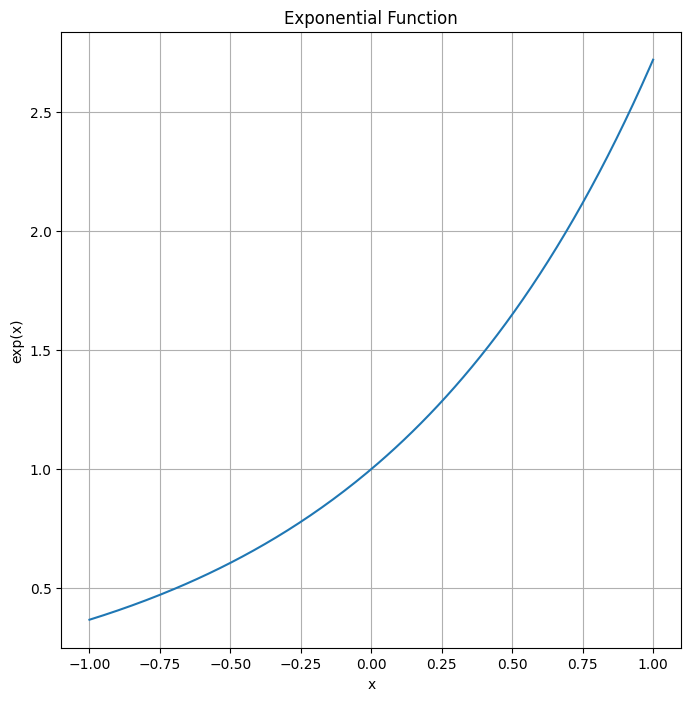

In [157]:
# Plot exponential function
x_value = np.linspace(-1, 1, 200)
plt.figure(figsize=(8, 8))
plt.plot(x_value, tf.exp(x_value))
plt.xlabel("x")
plt.ylabel("exp(x)")
plt.title("Exponential Function")
plt.grid(True)
plt.show()

In [158]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer="sgd")
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2621 - val_loss: 0.8295
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5822 - val_loss: 3.1567
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5104 - val_loss: 4.9145
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4942 - val_loss: 5.2536
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4940 - val_loss: 5.6912
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4406


0.4406219720840454

Alternatively, it's often preferable to replace the targets with the logarithm of the targets (and use no activation function in the output layer).

In [159]:
from scipy import optimize


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1),  # 預測 log(y)
])

optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

model.compile(
    loss="mse",
    optimizer=optimizer,
)

# 訓練時用 log 目標
model.fit(
    X_train_scaled,
    tf.math.log(y_train),
    epochs=5,
    validation_data=(X_valid_scaled, tf.math.log(y_valid)),
)

# 推論轉回正值
test_loss = model.evaluate(X_test_scaled, tf.math.log(y_test))
y_pred = tf.exp(model.predict(X_test_scaled))
test_loss

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7433 - val_loss: 0.3457
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2739 - val_loss: 0.2280
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2244 - val_loss: 0.2113
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2057 - val_loss: 0.1989
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1928 - val_loss: 0.1873
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1949
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.19485826790332794

- In this model (without `exponential_layer`), the network outputs a linear scalar (`Dense(1)`), and MSE directly minimizes the difference between predictions and targets. This is standard regression setup, stable and well-behaved.

- For strictly positive targets, a more robust strategy is to transform targets with `log(y)`, have the model predict `log(y)`, then apply `exp` at inference time. This avoids the extreme sensitivity that direct `exp` output can cause on gradients, especially when `y` varies across orders of magnitude.

- Key points:
  - `Dense(1) + MSE`: straightforward, easy to train.
  - `exponential_layer` at output can amplify values and may cause overflow/instability.
  - using `log(y)` targets makes this numerically safer; final prediction is `tf.exp(model.predict(...))`.

### Subclassing `tf.keras.layers.Layer`

`MyDense` is a simple custom layer implemented by subclassing `tf.keras.layers.Layer`, designed to mirror the behavior of `tf.keras.layers.Dense` while exposing the core layer API.

- It accepts `units` and `activation` in `__init__`, and calls `super().__init__(**kwargs)` so base-layer options (`name`, `dtype`, etc.) work.
- `build(batch_input_shape)` creates trainable weights:
  - `kernel` shape: `[input_dim, units]` with `he_normal` initialization
  - `bias` shape: `[units]` with zeros initialization
- `call(X)` is the forward pass: `X @ kernel + bias`, then apply activation.
- `get_config()` returns serializable config (including `units` and `activation`) so the layer is compatible with `model.save()` / `load_model(..., custom_objects=...)`.


In [160]:
class MyDense(tf.keras.layers.Layer):
    """A custom fully connected layer.

    This layer performs a linear transformation followed by an optional
    activation function, similar to `tf.keras.layers.Dense`.

    Args:
        units: Number of output units.
        activation: Activation function to apply. This can be a string,
            function, or `None`.
        **kwargs: Additional keyword arguments passed to the base
            `tf.keras.layers.Layer` class.
    """

    def __init__(self, units, activation=None, **kwargs):
        """Initializes the layer.

        Args:
            units: Number of output units.
            activation: Activation function to apply. This can be a string,
                function, or `None`.
            **kwargs: Additional keyword arguments passed to the base
                `tf.keras.layers.Layer` class.
        """
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        """Creates the layer's weights.

        Args:
            input_shape: Shape of the input tensor, including the batch
                dimension.
        """
        self.kernel = self.add_weight(
            name="kernel", shape=[input_shape[-1], self.units],
            initializer="he_normal")
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")

    def call(self, X):
        """Runs the forward pass.

        Args:
            X: Input tensor.

        Returns:
            The transformed tensor after applying the linear operation and
            activation function.
        """
        return self.activation(X @ self.kernel + self.bias)

    def get_config(self):
        """Returns the layer configuration for serialization.

        Returns:
            A dictionary containing the layer configuration.
        """
        base_config = super().get_config()
        return {**base_config, "units": self.units,
                "activation": tf.keras.activations.serialize(self.activation)}

In [161]:
# extra code – shows that a custom layer can be used normally
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    MyDense(30, activation="relu"),
    MyDense(1)
])
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)
model.save("my_model_with_a_custom_layer.keras")

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.0949 - val_loss: 6.9256
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8668 - val_loss: 2.6011
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7037


In [162]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_dense (MyDense)              │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_1 (MyDense)            │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 605 (2.37 KB)

In [163]:
# extra code – shows how to load a model with a custom layer
model = tf.keras.models.load_model("my_model_with_a_custom_layer.keras",
                                   custom_objects={"MyDense": MyDense})
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6481 - val_loss: 0.8613
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5347 - val_loss: 0.4588


In [164]:
class MyMultiLayer(tf.keras.layers.Layer):
    def call(self, X):
        X1, X2 = X # unpack the input tuple into two tensors
        print("X1.shape: ", X1.shape ," X2.shape: ", X2.shape)  # extra code
        return X1 + X2, X1 * X2, X1 / X2

Our custom layer can be called using the functional API like this:

In [165]:
# extra code – tests MyMultiLayer with symbolic inputs
inputs1 = tf.keras.layers.Input(shape=[2])
inputs2 = tf.keras.layers.Input(shape=[2])
MyMultiLayer()((inputs1, inputs2))

X1.shape:  (None, 2)  X2.shape:  (None, 2)


(<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_59>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_60>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_61>)

Note that the `call()` method receives symbolic inputs, and it returns symbolic outputs. The shapes are only partially specified at this stage: we don't know the batch size, which is why the first dimension is `None`.

We can also pass actual data to the custom layer:

In [166]:
# extra code – tests MyMultiLayer with actual data
import numpy as np

X1, X2 = np.array([[3., 6.], [2., 7.]]), np.array([[6., 12.], [4., 3.]])
MyMultiLayer()((X1, X2))

X1.shape:  (2, 2)  X2.shape:  (2, 2)


(<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[ 9., 18.],
        [ 6., 10.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[18., 72.],
        [ 8., 21.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[0.5      , 0.5      ],
        [0.5      , 2.3333333]], dtype=float32)>)

Now let's create a layer with a different behavior during training and testing:

In [167]:
class MyGaussianNoise(tf.keras.layers.Layer):
    """Applies Gaussian noise to inputs during training.

    This layer adds zero-mean Gaussian noise with standard deviation
    `stddev` when `training=True`. During inference, it returns the
    inputs unchanged.
    Args:
        stddev: Standard deviation of the Gaussian noise to add.
        **kwargs: Additional keyword arguments passed to the base
            `tf.keras.layers.Layer` class.
    """
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, X, training=None):
        """Applies Gaussian noise to the input during training.

        Args:
            X: Input tensor.
            training: Boolean indicating whether the layer is in training mode.

        Returns:
            Tensor with added Gaussian noise during training, or the original
            input tensor during inference.
        """

        if training:
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)
            return X + noise
        else:
            return X

It defines a custom Keras layer named `MyGaussianNoise`, which is designed to add random Gaussian noise to its input during the training phase of a neural network. This type of layer is often used as a regularization technique to prevent overfitting by making the model more robust to minor variations in the input data.

Here's a simple model that uses this custom layer:

In [168]:
# extra code – tests MyGaussianNoise
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    MyGaussianNoise(stddev=1.0),
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer="nadam")
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.2156 - val_loss: 25.1369
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4081 - val_loss: 14.9793
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1244


1.124422311782837

### Understanding the `call()` Method in Custom Layers

The `call()` method is where you define the **forward pass** logic of your custom layer. It specifies exactly how the input tensors are transformed into output tensors.

#### Arguments

- **`X`**: The input tensor (e.g., the output from the previous layer).
- **`training`**: A boolean argument that Keras automatically provides.
    - `True` during `model.fit()`.
    - `False` (or `None`) during `model.evaluate()` or `model.predict()`.
    - This allows the layer to exhibit different behaviors during training and inference (essential for layers like Dropout or Batch Normalization).

#### Implementing Conditional Logic

In the `MyGaussianNoise` example, the logic is split based on the `training` flag:

1.  **During Training (`if training`)**:
    *   **Generate Noise**: `tf.random.normal(tf.shape(X), stddev=self.stddev)` creates a noise tensor with the same shape as the input.
    *   **Apply Transformation**: The noise is added to the input: `return X + noise`.
    *   **Goal**: By perturbing the data, the model is forced to learn robust features, acting as a form of **regularization** to prevent overfitting.

2.  **During Inference (`else`)**:
    *   **Bypass**: The layer simply returns `X` unchanged.
    *   **Goal**: During evaluation or deployment, we want deterministic and clean predictions without random fluctuations.

#### Key Takeaway

By utilizing the `training` argument within `call()`, you can build sophisticated layers that dynamically adapt their behavior, ensuring your model generalizes well during training while remaining stable during prediction.

---
## Custom Models
When the standard Sequential or Functional APIs are not flexible enough for your needs, you can create a **custom model** by subclassing `tf.keras.Model`. This allows you to implement complex architectures, including models with loops, conditional logic, or multiple inputs and outputs.

### Steps to Build a Custom Model
1.  **Subclass `tf.keras.Model`**: Define a new class that inherits from the Keras Model base class.
2.  **Define Layers in `__init__()`**: Create the layers you need (including standard Keras layers or custom ones like `MyDense`) and save them as attributes of the instance.
3.  **Implement the Forward Pass in `call()`**: Define exactly how the inputs should be processed to produce the outputs. You can use any TensorFlow operation here to specify the data flow.
4.  **Serialization with `get_config()`**: If your model has custom initialization parameters, implement this method to return a dictionary of those parameters, ensuring the model can be saved and reloaded correctly.

Once your custom model is defined, you can use it just like any other Keras model by calling standard methods such as `compile()`, `fit()`, `evaluate()`, and `predict()`.

First, we define a custom layer called `ResidualBlock`, which implements a simple residual block commonly used in deep learning architectures.
In `__init__`, it creates `n_layers` dense ReLU sublayers with He normal initialization. In `call`, it feeds `inputs` through all those sublayers into `Z`, then returns `inputs + Z`, so the block learns a residual correction instead of a full transformation. This pattern helps gradients flow in deep networks and makes training deep models more stable.

In [169]:
class ResidualBlock(tf.keras.layers.Layer):
    """Residual block made of Dense-ReLU layers with a skip connection.

    This layer applies a stack of fully connected hidden layers to the input
    and adds the original input tensor to the transformed output.

    Attributes:
        hidden: List of `tf.keras.layers.Dense` layers.
    """

    def __init__(self, n_layers, n_neurons, **kwargs):
        """Initializes the residual block.

        Args:
            n_layers: Number of hidden Dense layers in the residual branch.
            n_neurons: Number of neurons in each hidden Dense layer.
            **kwargs: Additional keyword arguments for `tf.keras.layers.Layer`.
        """
        super().__init__(**kwargs)
        self.hidden = [
            tf.keras.layers.Dense(
                n_neurons,
                activation="relu",
                kernel_initializer="he_normal",
            )
            for _ in range(n_layers)
        ]

    def call(self, inputs):
        """Runs the forward pass.

        Args:
            inputs: Input tensor.

        Returns:
            Tensor equal to `inputs + F(inputs)`, where `F` is the stacked
            hidden transformation.
        """
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        return inputs + Z

In [170]:
class ResidualRegressor(tf.keras.Model):
    """A custom residual regression model built by subclassing `tf.keras.Model`.

    The model applies an initial dense projection, passes features through
    repeated residual blocks, then maps to the requested output dimension.
    """

    def __init__(self, output_dim, **kwargs):
        """Initializes the residual regressor.

        Args:
            output_dim: Number of output units in the final dense layer.
            **kwargs: Additional keyword arguments passed to `tf.keras.Model`.
        """
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.hidden1 = tf.keras.layers.Dense(
            30, activation="relu", kernel_initializer="he_normal"
        )
        self.block1 = ResidualBlock(2, 30)
        self.block2 = ResidualBlock(2, 30)
        self.out = tf.keras.layers.Dense(output_dim)

    def call(self, inputs, training=None, mask=None):
        """Runs the forward pass.

        Args:
            inputs: Input tensor.
            training: Boolean or None indicating training/inference mode.
            mask: Optional mask tensor (unused).

        Returns:
            Output tensor of shape `(batch_size, output_dim)`.
        """
        Z = self.hidden1(inputs)
        for _ in range(1 + 3):
            Z = self.block1(Z)
        Z = self.block2(Z)
        return self.out(Z)

    def get_config(self):
        """Returns the model configuration for serialization.

        Returns:
            A dictionary containing the base config and `output_dim`.
        """
        base_config = super().get_config()
        return {**base_config, "output_dim": self.output_dim}

In [171]:
# extra code – shows that the model can be used normally
tf.keras.utils.set_random_seed(42)
model = ResidualRegressor(1)
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=2, validation_data=(X_valid_scaled, y_valid))
score = model.evaluate(X_test_scaled, y_test)
model.save("my_custom_model.keras")

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 29.9859 - val_loss: 2.0637
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4475 - val_loss: 1.2054
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1703


In [172]:
# extra code – the model can be loaded and you can continue training or use it
#              to make predictions
model = tf.keras.models.load_model(
    "my_custom_model.keras",
    custom_objects={"ResidualRegressor": ResidualRegressor}
)
history = model.fit(X_train_scaled, y_train, epochs=2, validation_data=(X_valid_scaled, y_valid))
list(zip(model.predict(X_test_scaled[:3]), y_test[:3]))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9941 - val_loss: 6.5679
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1565 - val_loss: 27.3594
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


[(array([0.7185668], dtype=float32), array([0.477])),
 (array([1.1036984], dtype=float32), array([0.458])),
 (array([3.9145215], dtype=float32), array([5.00001]))]

We could have defined the model using the sequential API instead:

In [173]:
tf.keras.utils.set_random_seed(42)
block1 = ResidualBlock(n_layers=2, n_neurons=30)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),
    block1, block1, block1, block1,
    ResidualBlock(n_layers=2, n_neurons=30),
    tf.keras.layers.Dense(1)
])

### Custom Model Using the Sequential API

The cell above demonstrates an **alternative way** to build the same `ResidualRegressor` architecture using the **Sequential API** instead of subclassing `tf.keras.Model`.

#### Key Observations

- **`block1` is reused 4 times** by passing the same instance repeatedly:
    ```python
    block1, block1, block1, block1,
    ```
    This means all four positions **share the same weights**, unlike creating four separate `ResidualBlock` instances.

- **A new `ResidualBlock`** is created inline for the fifth block, so it has its **own independent weights**.

#### Comparison with `ResidualRegressor`

| Aspect | `ResidualRegressor` (subclass) | Sequential API |
|---|---|---|
| Weight sharing | Explicit (`self.block1` reused) | Via shared `block1` instance |
| Flexibility | Higher (custom `call()` logic) | Limited to linear stack |
| Readability | More verbose | More concise |

#### When to Use Each

- Use **subclassing** when you need custom forward-pass logic, multiple inputs/outputs, or conditional computation.
- Use the **Sequential API** when the architecture is a simple linear stack of layers, even with shared blocks.

In [174]:
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=2, validation_data=(X_valid_scaled, y_valid))
score = model.evaluate(X_test_scaled, y_test)

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.4615 - val_loss: 2.2051
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7835 - val_loss: 2.2003
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6428


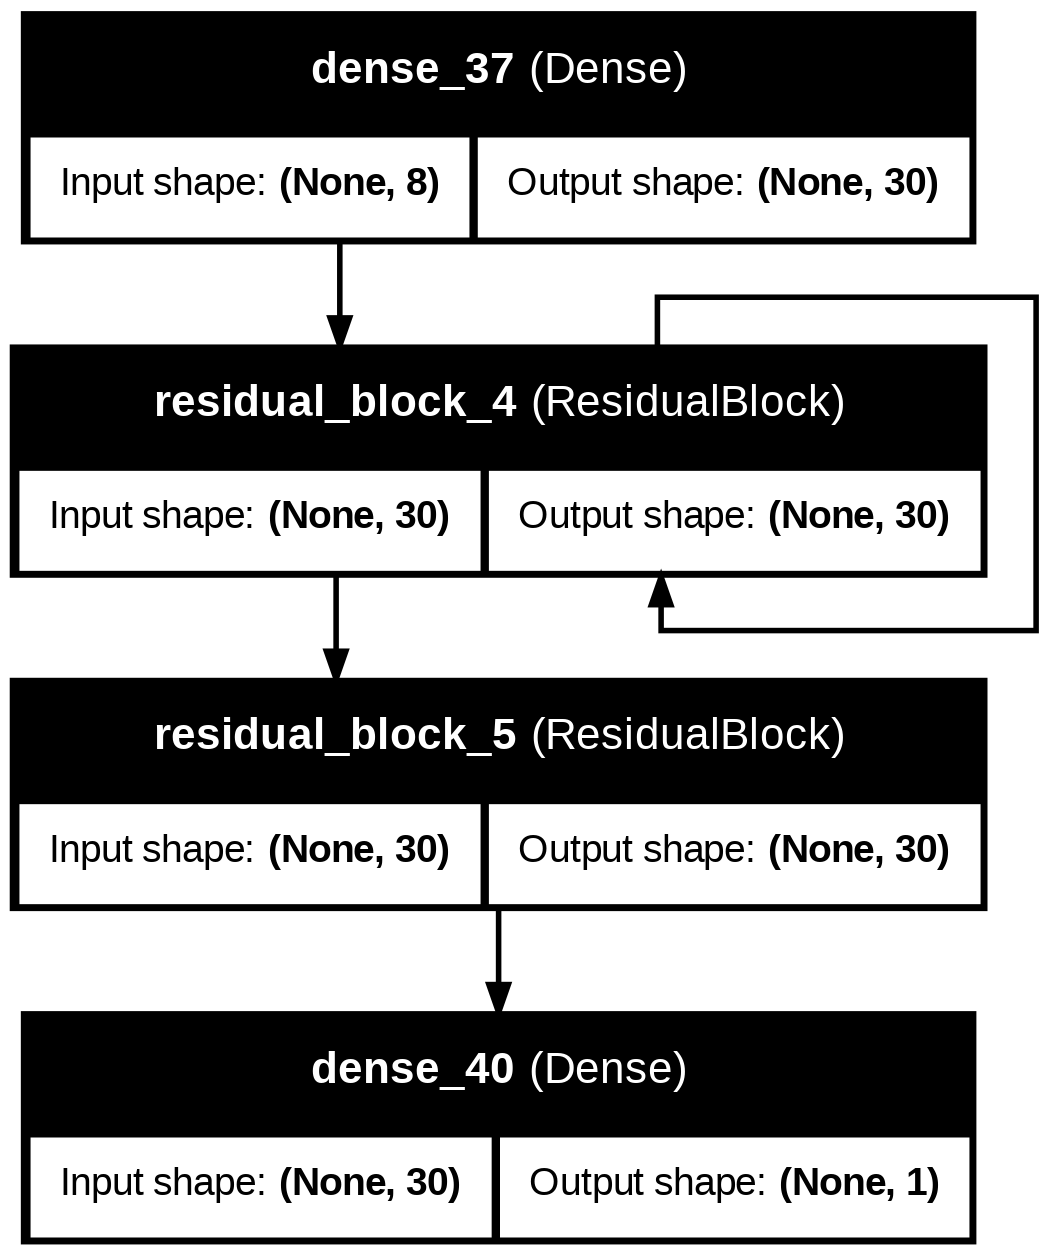

In [175]:
# Visualize the model architecture
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, expand_nested=True)

In [176]:
model.layers

[<Dense name=dense_37, built=True>,
 <ResidualBlock name=residual_block_4, built=True>,
 <ResidualBlock name=residual_block_4, built=True>,
 <ResidualBlock name=residual_block_4, built=True>,
 <ResidualBlock name=residual_block_4, built=True>,
 <ResidualBlock name=residual_block_5, built=True>,
 <Dense name=dense_40, built=True>]

---
## Losses Based on Model Internals

Sometimes you want to define a loss that depends not just on the predictions and targets, but also on other parts of the model (e.g., internal layer outputs, weights, or activations). This is useful for implementing regularization techniques, adversarial training, or custom architectures that require access to intermediate representations.

In Keras, you can create such losses by:

1. **Subclassing `tf.keras.losses.Loss`** and accessing model components through the training context.
2. **Using model callbacks** to track internal states during training.
3. **Implementing custom training loops** with `tf.GradientTape` for full control over loss computation.

This approach enables advanced techniques like activity regularization, feature matching, and other sophisticated training strategies.


**Warning**: the `add_metric()` method was deprecated and removed in recent TF versions. Metrics (custom or not) must now be passed to the model via the `metrics` argument of the `model.compile()` method.

In [177]:
class ReconstructingRegressor(tf.keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(5)]
        self.out = tf.keras.layers.Dense(output_dim)

    def build(self, batch_input_shape):
        n_inputs = batch_input_shape[-1]
        self.reconstruct = tf.keras.layers.Dense(n_inputs)

    def call(self, inputs, training=None):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        reconstruction = self.reconstruct(Z)
        recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
        self.add_loss(0.05 * recon_loss)
        return self.out(Z)

**build Method**

The build method is a Keras lifecycle method that is called the first time the model processes input, or when `model.build()` is explicitly called. It's typically used to create layers whose weights or shape depend on the input shape.
- `n_inputs = batch_input_shape[-1]`: This extracts the number of features (or dimensions) from the input tensor's shape. `batch_input_shape` would be a tuple like `(batch_size, num_features)`, so `[-1]` gets `num_features`.
- `self.reconstruct = tf.keras.layers.Dense(n_inputs)`: This creates a Dense layer named `self.reconstruct`. This layer is responsible for taking the compressed representation from the hidden layers and expanding it back to the original input dimension. This is the "decoder" part for the reconstruction task.

**call Method**
This method defines the forward pass of the model, specifying how input data is processed through the layers to produce output.

- `Z = inputs`: The input tensor is assigned to Z.
- `for layer in self.hidden: Z = layer(Z)`: The input Z is passed sequentially through each of the five hidden Dense layers defined in `__init__`.
- `reconstruction = self.reconstruct(Z)`: The output of the hidden layers (Z) is then fed into the `self.reconstruct` layer to generate a reconstruction of the original inputs.
- `recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))`: This line calculates the reconstruction loss.
    - `reconstruction - inputs`: Computes the element-wise difference between the reconstructed output and the original input.
    - `tf.square(...)`: Squares each element of this difference. This is a common way to penalize larger errors more heavily (Mean Squared Error components).
    - `tf.reduce_mean(...)`: Computes the mean of all squared differences, yielding a single scalar value representing the overall reconstruction error.
- `self.add_loss(0.05 * recon_loss)`: This is a key feature of Keras custom models. It adds the calculated recon_loss (scaled by 0.05) to the model's total loss. This means that during training, the optimizer will try to minimize both the primary regression loss and this auxiliary reconstruction loss, effectively encouraging the hidden layers to learn representations that are useful for reconstructing the input.
- `return self.out(Z)`: Finally, the model returns the output of the primary regression layer (self.out), using the processed features Z.

In [178]:
# extra code
tf.keras.utils.set_random_seed(42)
model = ReconstructingRegressor(1)
model.compile(loss="mse", optimizer="nadam")
history = model.fit(X_train_scaled, y_train, epochs=5)
model.evaluate(X_test_scaled, y_test)

Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7571
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5037
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4193
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4187
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3705
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3726


0.3726007342338562

---
## Computing Gradients Using Autodiff

To implement custom training loops or complex model architectures, you often need to compute gradients of functions with respect to specific variables. TensorFlow provides **Automatic Differentiation (Autodiff)** via the `tf.GradientTape` API.

### How it Works

1. **Define Variables**: Create `tf.Variable` objects that you want to track.
2. **Record Operations**: Wrap your mathematical operations inside a `with tf.GradientTape() as tape:` block. TensorFlow "records" every operation involving watched tensors onto a "tape".
3. **Calculate Gradients**: Call `tape.gradient(target, sources)` to compute the derivative of the `target` (e.g., a loss value) with respect to the `sources` (e.g., weights).

### Mathematical Example

Consider the function:
$$f(w_1, w_2) = 3w_1^2 + 2w_1w_2$$

To find the gradients at a specific point $(w_1, w_2)$:
- The partial derivative with respect to $w_1$ is: $\frac{\partial f}{\partial w_1} = 6w_1 + 2w_2$
- The partial derivative with respect to $w_2$ is: $\frac{\partial f}{\partial w_2} = 2w_1$

### Key Concepts

*   **Variables vs. Tensors**: By default, the tape only tracks `tf.Variable` objects. To track a constant `tf.Tensor`, you must explicitly call `tape.watch(tensor)`.
*   **Persistent Tapes**: A standard tape is erased immediately after `tape.gradient()` is called. To compute multiple gradients (e.g., for different parts of a model), use `tf.GradientTape(persistent=True)`.
*   **Higher-Order Gradients**: You can nest tapes to compute second-order derivatives (Hessians) or higher.

In [179]:
# define a simple function f(w1, w2) = 3w1^2 + 2w1*w2
def f(w1, w2):
    """ A simple function of two variables w1 and w2, defined as f(w1, w2) = 3w1^2 + 2w1*w2. This function can be used to demonstrate how to compute gradients with respect to its inputs using TensorFlow's automatic differentiation capabilities."""
    return 3 * w1 ** 2 + 2 * w1 * w2

In [180]:
w1, w2 = 5, 3
eps = 1e-6

# Numerical approximation of the partial derivative of f with respect to w1
# using the finite difference method: (f(w1 + eps, w2) - f(w1, w2)) / eps
# Expected: df/dw1 = 6*w1 + 2*w2 = 6*5 + 2*3 = 36
(f(w1 + eps, w2) - f(w1, w2)) / eps

36.000003007075065

In [181]:
# Numerical approximation of the partial derivative of f with respect to w2
(f(w1, w2 + eps) - f(w1, w2)) / eps

10.000000003174137

Compute exact gradients using TensorFlow's automatic differentiation feature specifically with `tf.GradientTape`. This mechanism is fundamental for training neural networks, as it efficiently calculates the derivatives needed for optimization algorithms like Gradient Descent.

In [182]:
w1, w2 = tf.Variable(5.), tf.Variable(3.)
with tf.GradientTape() as tape:
    z = f(w1, w2)

gradients = tape.gradient(z, [w1, w2])


The process begins by defining the variables $w_1$ and $w_2$ as `tf.Variable` objects. In TensorFlow, `tf.Variable` instances are special tensors that hold mutable state and are automatically "watched" by `tf.GradientTape` by default. This "watching" means that any operation performed on these variables within the `tf.GradientTape` context will be recorded, allowing TensorFlow to trace the computational graph. Here, $w_1$ is initialized to $5.0$ and $w_2$ to $3.0$.

The core of the automatic differentiation is encapsulated within the `with tf.GradientTape() as tape:` block. This context manager ensures that all differentiable operations performed inside its scope are recorded. When the function $f(w_1, w_2) = 3w_1^2 + 2w_1w_2$ is evaluated as `z = f(w1, w2)` within this block, TensorFlow constructs a computational graph that links the output `z` back to its input variables `w1` and `w2`. At the given values, $z$ evaluates to $3(5^2) + 2(5)(3) = 3(25) + 30 = 75 + 30 = 105.0$.

Finally, `gradients = tape.gradient(z, [w1, w2])` is called to compute the gradients. This method takes the target tensor (`z`) and a list of source tensors (`[w1, w2]`) and calculates the partial derivatives of the target with respect to each of the source tensors. Mathematically, these are $\frac{\partial f}{\partial w_1}$ and $\frac{\partial f}{\partial w_2}$.
For the function $f(w_1, w_2) = 3w_1^2 + 2w_1w_2$:
*   The partial derivative with respect to $w_1$ is $\frac{\partial f}{\partial w_1} = 6w_1 + 2w_2$.
*   The partial derivative with respect to $w_2$ is $\frac{\partial f}{\partial w_2} = 2w_1$.

Substituting the values $w_1=5$ and $w_2=3$:
*   $\frac{\partial f}{\partial w_1} = 6(5) + 2(3) = 30 + 6 = 36$.
*   $\frac{\partial f}{\partial w_2} = 2(5) = 10$.

The `tf.GradientTape` successfully computes these exact gradients, returning `[36.0, 10.0]`, which matches the manual calculation, demonstrating its accuracy and utility for backpropagation in machine learning models.

In [183]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [184]:
with tf.GradientTape() as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)  # returns tensor 36.0
try:
    dz_dw2 = tape.gradient(z, w2)  # raises a RuntimeError!
except RuntimeError as ex:
    print(ex)

A non-persistent GradientTape can only be used to compute one set of gradients (or jacobians)


It demonstrates how to correctly calculate both dz_dw1 and dz_dw2 by initializing `tf.GradientTape` with `persistent=True`. This allows multiple calls to `tape.gradient()` within the same tape context. As a result, the code `dz_dw1, dz_dw2` will output the computed gradient values as `(<tf.Tensor: shape=(), dtype=float32, numpy=36.0>, <tf.Tensor: shape=(), dtype=float32, numpy=10.0>)`, confirming the partial derivatives.

In [185]:
with tf.GradientTape(persistent=True) as tape: # create a persistent tape to compute multiple gradients
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)  # returns tensor 36.0
dz_dw2 = tape.gradient(z, w2)  # returns tensor 10.0, works fine now!
del tape # free up resources used by the tape

In [186]:
dz_dw1, dz_dw2

(<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>)

If `c1` and `c2` are constants (not `tf.Variable`), they are not automatically tracked by the tape. To compute gradients with respect to them, you must explicitly tell the tape to watch these tensors using `tape.watch(c1)` and `tape.watch(c2)`. This allows the tape to include them in the computational graph and compute their gradients when `tape.gradient()` is called.

In [187]:
c1, c2 = tf.constant(5.), tf.constant(3.)
with tf.GradientTape() as tape:
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [188]:
gradients

[None, None]

In [189]:
with tf.GradientTape() as tape:
    tape.watch(c1) # tell the tape to watch c1, which is a constant, so it can compute the gradient with respect to it
    # tape.watch(c2)
    z = f(c1, c2)

gradients = tape.gradient(z, [c1, c2])

In [190]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>, None]

In [191]:
# extra code – if given a vector, tape.gradient() will compute the gradient of
#              the vector's sum.
with tf.GradientTape() as tape:
    z1 = f(w1, w2 + 2.)
    z2 = f(w1, w2 + 5.)
    z3 = f(w1, w2 + 7.)

tape.gradient([z1, z2, z3], [w1, w2])

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

### `tape.gradient([z1, z2, z3], [w1, w2])`

This is the crucial part. When `tape.gradient()` is called with a **list of target tensors** (e.g., `[z1, z2, z3]`) and a **list of source tensors** (e.g., `[w1, w2]`), it computes the gradient of the **sum** of the target tensors with respect to each of the source tensors.

#### Mathematical Formulation

For each source variable, the gradient is computed as:

$$\frac{\partial(z_1 + z_2 + z_3)}{\partial w_1} \quad \text{and} \quad \frac{\partial(z_1 + z_2 + z_3)}{\partial w_2}$$

This is equivalent to summing the individual partial derivatives:

$$\frac{\partial z_1}{\partial w_1} + \frac{\partial z_2}{\partial w_1} + \frac{\partial z_3}{\partial w_1} \quad \text{and} \quad \frac{\partial z_1}{\partial w_2} + \frac{\partial z_2}{\partial w_2} + \frac{\partial z_3}{\partial w_2}$$

The result is a list containing these **aggregated gradient values** for `w1` and `w2` respectively.


In [192]:
# extra code – shows that we get the same result as the previous cell
with tf.GradientTape() as tape:
    z1 = f(w1, w2 + 2.)
    z2 = f(w1, w2 + 5.)
    z3 = f(w1, w2 + 7.)
    z = z1 + z2 + z3

tape.gradient(z, [w1, w2])

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

### Higher-Order Gradients
To compute second-order gradients (the Hessian), you can nest `tf.GradientTape` contexts. The outer tape will compute the gradient of the first-order gradients.

In [193]:
# extra code – shows how to compute the jacobians and the hessians
with tf.GradientTape(persistent=True) as hessian_tape:
    with tf.GradientTape() as jacobian_tape:
        z = f(w1, w2)
    jacobians = jacobian_tape.gradient(z, [w1, w2])
hessians = [hessian_tape.gradient(tf.convert_to_tensor(jacobian), [w1, w2])
            for jacobian in jacobians]
del hessian_tape

In [194]:
jacobians

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [195]:
hessians

[[<tf.Tensor: shape=(), dtype=float32, numpy=6.0>,
  <tf.Tensor: shape=(), dtype=float32, numpy=2.0>],
 [<tf.Tensor: shape=(), dtype=float32, numpy=2.0>, None]]

### Excluding Variables from Gradient Computation
If you want to compute gradients with respect to some variables while treating others as constants, you can use `stop_gradient` to prevent gradients from flowing through certain parts of the graph. For example:

In [196]:
def f(w1, w2):
    return 3 * w1 ** 2 + tf.stop_gradient(2 * w1 * w2)

with tf.GradientTape() as tape:
    z = f(w1, w2)  # same result as without stop_gradient()

gradients = tape.gradient(z, [w1, w2])

In essence, `tf.stop_gradient()` allows you to selectively exclude certain parts of your computation graph from gradient calculation, which can be useful for various scenarios such as implementing custom loss functions, ensuring specific parameters remain fixed during training, or when you only want to backpropagate through certain branches of a complex model.

In [197]:
gradients

[<tf.Tensor: shape=(), dtype=float32, numpy=30.0>, None]

In [198]:
print(gradients[1])

None


`tf.stop_gradient()` blocks gradients **only through the wrapped sub-expression**, while leaving the forward value unchanged.

For
$$
f(w_1, w_2) = 3w_1^2 + \operatorname{stop\_gradient}(2w_1 w_2),
$$
at \(w_1 = 5\) and \(w_2 = 3\):

- The forward value is unchanged:
    $$
    z = 3 \cdot 5^2 + 2 \cdot 5 \cdot 3 = 105.
    $$

- `tape.gradient(z, [w1, w2])` returns:
    - `30.0` for `w1`, coming only from \(3w_1^2\), since
        $$
        \frac{\partial}{\partial w_1}(3w_1^2) = 6w_1 = 30
        $$
    - `None` for `w2`, because there is no gradient path through the stopped term.

- `None` means TensorFlow found **no differentiable path** from `z` to that source.
- `None` is different from a numeric `0.0`, which means a valid path exists but the slope is zero.
- Use `tf.stop_gradient()` to freeze part of the computation graph during backpropagation without changing the forward computation.

In [199]:
x = tf.Variable(1e-50)
with tf.GradientTape() as tape:
    z = tf.sqrt(x)

tape.gradient(z, [x])

[<tf.Tensor: shape=(), dtype=float32, numpy=inf>]

Concept:
- `x` is a trainable variable initialized to `1e-50`.
- `z = sqrt(x)` computes the square root of `x`.
- `tape.gradient(z, x)` computes the gradient of `z` with respect to `x`, which is mathematically:
    $$
    \frac{dz}{dx} = \frac{1}{2\sqrt{x}}
    $$
- At `x = 1e-50`, this gradient becomes:
    $$
    \frac{1}{2\sqrt{1e-50}} = \frac{1}{2 \cdot 1e-25} = 5e+24
    $$
This extremely large gradient can lead to numerical instability during training, causing the optimizer to take excessively large steps and potentially diverge. To mitigate this issue, you can use `tf.clip_by_value()` to limit the maximum value of the gradient, ensuring that it remains within a reasonable range and prevents overflow or divergence during optimization.

In [200]:
tf.math.log(tf.exp(tf.constant(30., dtype=tf.float32)) + 1.)

<tf.Tensor: shape=(), dtype=float32, numpy=30.0>

In [201]:
x = tf.Variable([1.0e30])
with tf.GradientTape() as tape:
    z = my_softplus(x)

tape.gradient(z, [x])

[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([nan], dtype=float32)>]

In [202]:
def my_softplus(z):
    return tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)

Here is the proof that this equation is equal to log(1 + exp(_z_)):
* softplus(_z_) = log(1 + exp(_z_))
* softplus(_z_) = log(1 + exp(_z_)) - log(exp(_z_)) + log(exp(_z_)) ; **just adding and subtracting the same value**
* softplus(_z_) = log\[(1 + exp(_z_)) / exp(_z_)\] + log(exp(_z_)) ; **since log(_a_) - log(_b_) = log(_a_ / _b_)**
* softplus(_z_) = log\[(1 + exp(_z_)) / exp(_z_)\] + _z_ ; **since log(exp(_z_)) = _z_**
* softplus(_z_) = log\[1 / exp(_z_) + exp(_z_) / exp(_z_)\] + _z_ ; **since (1 + _a_) / _b_ = 1 / _b_ + _a_ / _b_**
* softplus(_z_) = log\[exp(–_z_) + 1\] + _z_ ; **since 1 / exp(_z_) = exp(–z), and exp(_z_) / exp(_z_) = 1**
* softplus(_z_) = softplus(–_z_) + _z_ ; **we recognize the definition at the top, but with –_z_**
* softplus(_z_) = softplus(–|_z_|) + max(0, _z_) ; **if you consider both cases, _z_ < 0 or _z_ ≥ 0, you will see that this works**

In [203]:
@tf.custom_gradient
def my_softplus(z):
    def my_softplus_gradients(grads):  # grads = backprop'ed from upper layers
        return grads * (1 - 1 / (1 + tf.exp(z)))  # stable grads of softplus

    result = tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)
    return result, my_softplus_gradients

In [204]:
# extra code – shows that the function is now stable, as well as its gradients
x = tf.Variable([1000.])
with tf.GradientTape() as tape:
    z = my_softplus(x)

z, tape.gradient(z, [x])

(<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1000.], dtype=float32)>,
 [<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>])

---
## Custom Training Loops

While `model.fit()` is powerful, writing a custom training loop provides complete control over the training process. This is essential for advanced architectures like GANs, or when using multiple optimizers and complex loss schedules.

### Workflow

1.  **Initialization**: Define your model, loss function, optimizer, and metrics.
2.  **Data Iteration**: Use a `tf.data.Dataset` to iterate through epochs and batches.
3.  **Forward Pass**: Inside a `tf.GradientTape`, compute predictions and calculate the loss.
4.  **Backward Pass**: Use the tape to compute gradients of the loss with respect to the model's trainable variables.
5.  **Update Weights**: Use the optimizer to apply these gradients to the variables.
6.  **Metric Tracking**: Update your metrics with the batch results and display them.

This approach allows you to debug the training process step-by-step and implement logic that the standard API cannot easily accommodate.

In [205]:
tf.keras.utils.set_random_seed(42)  # extra code – to ensure reproducibility
l2_reg = tf.keras.regularizers.l2(0.05)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=l2_reg),
    tf.keras.layers.Dense(1, kernel_regularizer=l2_reg)
])

we create a Sequential model with two Dense layers, each regularized with L2 regularization (penalty factor 0.05) to prevent overfitting by penalizing large weights.

Then, we define a custom function `random_batch(X, y, batch_size=32)` that generates random batches of data from the input features `X` and labels `y`. This function randomly selects `batch_size` indices from the dataset and returns the corresponding subsets of `X` and `y`.

In [206]:
import numpy as np
def random_batch(X, y, batch_size=32):
    idx = np.random.randint(len(X), size=batch_size)
    return X[idx], y[idx]

In [207]:
def print_status_bar(step, total, loss, metrics=None):
    """Prints a one-line training progress status bar.

    Args:
        step: Current training step (1-based or 0-based based on caller usage).
        total: Total number of steps in the current epoch/loop.
        loss: A Keras metric-like object (e.g., `tf.keras.metrics.Mean`) with
            `name` and `result()` attributes.
        metrics: Optional list of additional metric-like objects, each exposing
            `name` and `result()`.

    Returns:
        None. Prints formatted progress text to stdout.
    """
    metrics = " - ".join([f"{m.name}: {m.result():.4f}"
                          for m in [loss] + (metrics or [])])
    end = "" if step < total else "\n"
    print(f"\r{step}/{total} - " + metrics, end=end)

In [208]:
tf.keras.utils.set_random_seed(42)

**Warning**: the `tf.keras.losses.mean_squared_error()` function not longer exists, you must use `tf.keras.losses.MeanSquaredError` class instead.

In [209]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size # number of batches per epoch
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_fn = tf.keras.losses.MeanSquaredError()
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.MeanAbsoluteError()]

In [210]:
for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}")
    for step in range(1, n_steps + 1):
        # get a random batch of data for this step
        X_batch, y_batch = random_batch(X=X_train_scaled, y=y_train, batch_size=batch_size)

        # compute the loss and gradients, and update the weights
        with tf.GradientTape() as tape:
            # forward pass to compute predictions
            y_pred = model(X_batch, training=True)
            # compute the main loss for this batch using the loss function
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
            # add any additional losses (e.g., regularization losses) to the main loss
            loss = tf.add_n([main_loss] + model.losses)

        # compute the gradients of the loss with respect to the model's trainable variables and apply the gradients to update the weights
        gradients = tape.gradient(loss, model.trainable_variables)

        # apply the gradients to update the model's trainable variables using the optimizer
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # extra code – if your model has variable constraints
        for variable in model.variables:
            if variable.constraint is not None:
                variable.assign(variable.constraint(variable))

        # update the state of the loss and metrics with the current batch's results, so that they can compute the average loss and metrics across all batches seen so far in this epoch
        mean_loss(loss)
        for metric in metrics:
            metric(y_batch, y_pred)

        print_status_bar(step, n_steps, mean_loss, metrics)

    # reset the state of the loss and metrics at the end of each epoch, so that they start fresh for the next epoch
    for metric in [mean_loss] + metrics:
        metric.reset_state()

Epoch 1/5
362/362 - mean: 3.5419 - mean_absolute_error: 0.6640
Epoch 2/5
362/362 - mean: 1.8693 - mean_absolute_error: 0.5431
Epoch 3/5
362/362 - mean: 1.1428 - mean_absolute_error: 0.5030
Epoch 4/5
362/362 - mean: 0.8501 - mean_absolute_error: 0.4977
Epoch 5/5
362/362 - mean: 0.7280 - mean_absolute_error: 0.5014


This loop is a manual training loop for a TensorFlow model, doing the work that `model.fit()` normally does for you.

Outer loop over `epoch`: for each epoch it prints the epoch header and runs the inner step loop.  
Inner loop over `step`: samples a random mini-batch from training data with `random_batch(...)`; this is SGD-style batch training.

`tf.GradientTape()` creates a context that records operations so gradients can be computed.  
Within it:
- `model(X_batch, training=True)` runs the forward pass and returns predictions.
- `loss_fn(y_batch, y_pred)` computes per-sample losses; `tf.reduce_mean(...)` gives batch-average `main_loss` which is the primary data loss (MSE in this case).
- `loss = tf.add_n([main_loss] + model.losses)` adds any layer-provided losses (e.g., regularization penalties from `kernel_regularizer`) to the main data loss.
    - `main_loss` is the average MSE for the batch.
    - `model.losses` is a list of any additional losses added by layers (like regularization terms).
    - `tf.add_n(...)` sums them all together with the main loss to get the total loss for this batch.
- thus, `tape` records all operations that lead to `loss`, so we can compute gradients with respect to model weights.

After tape:
- `tape.gradient(loss, model.trainable_variables)` computes gradients for all trainable weights.
- `optimizer.apply_gradients(...)` updates weights with those gradients.
    - `zip(gradients, model.trainable_variables)` pairs each gradient with its corresponding variable for the optimizer to update.
    - `optimizer` (e.g., Adam) uses these gradients to perform a step of optimization, adjusting the model's weights to minimize the loss.
- If variables have constraints (e.g., non-negativity), `variable.assign(variable.constraint(variable))` enforces them.

Metrics:
- `mean_loss(loss)` updates a `tf.keras.metrics.Mean` tracker.
- each metric in `metrics` (e.g., accuracy) is updated with batch labels/predictions.
- `print_status_bar(...)` prints a one-line progress summary.

At epoch end, reset all metrics with `metric.reset_state()` so next epoch starts fresh.

In [211]:
# extra code – shows how to use the tqdm package to display nice progress bars

from tqdm.notebook import trange
from collections import OrderedDict
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train_scaled, y_train)
                with tf.GradientTape() as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)

                gradients = tape.gradient(loss, model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))

                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))

                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()

                steps.set_postfix(status)

        for metric in [mean_loss] + metrics:
            metric.reset_state()

All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/362 [00:00<?, ?it/s]

### Custom Keras Training Loop with `tqdm` Progress Bars

This cell demonstrates how to build a **manual training loop** in TensorFlow/Keras and make it easier to monitor by adding `tqdm` notebook progress bars.

---

#### 1) Why use this pattern?

`model.fit()` is convenient, but a custom loop gives full control over:

- how batches are sampled,
- how losses are combined,
- when gradients are applied,
- how metrics are computed and displayed.

Using `trange(...)` from `tqdm.notebook` adds:

- epoch and step progress,
- ETA/time remaining,
- live metric updates in the notebook UI.

---

#### 2) Epoch and batch iteration

Two nested loops are used:

- outer loop: epochs (`1 ... n_epochs`)
- inner loop: training steps (`1 ... n_steps`)

At each step, a random mini-batch is sampled:

- `X_batch, y_batch = random_batch(X_train_scaled, y_train)`

This performs SGD-style stochastic updates.

---

#### 3) Forward pass and total loss

Inside `tf.GradientTape()`:

1. Compute predictions  
    `y_pred = model(X_batch, training=True)`

2. Compute data loss (batch MSE)  
    `main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))`

3. Add regularization/internal losses  
    `loss = tf.add_n([main_loss] + model.losses)`

`model.losses` typically includes layer penalties such as L2 regularization, so optimization uses both prediction error and regularization.

---

#### 4) Backpropagation and parameter update

After leaving the tape context:

- compute gradients  
  `gradients = tape.gradient(loss, model.trainable_variables)`

- apply gradients  
  `optimizer.apply_gradients(zip(gradients, model.trainable_variables))`

Optional post-update constraint handling is then applied for variables that define a constraint (e.g., non-negativity).

---

#### 5) Metrics and live progress display

Each step updates:

- `mean_loss`
- additional metrics in `metrics` (e.g., MAE)

A `status` dictionary is passed to:

- `steps.set_postfix(status)`

This makes the progress bar show live values like current loss and MAE.

At the end of each epoch:

- reset metric state with `metric.reset_state()`  
so the next epoch starts with clean metric tracking.

---

#### 6) Key takeaway

This is the standard custom-training-loop workflow (forward pass → loss → gradients → optimizer step), enhanced with `tqdm` for better observability and notebook-friendly monitoring.

---
## TensorFlow Functions
TensorFlow Functions are Python functions that have been converted into optimized computation graphs using the `@tf.function` decorator. This process allows TensorFlow to perform optimizations like constant folding and parallelization, typically leading to faster execution compared to eager mode. They are also essential for exporting models for deployment in production environments.

First, we define a plain Python function `cube(x)` that computes the cube of its input. When we call this function with a TensorFlow tensor, it executes in eager mode, which is straightforward and easy to debug.

In [212]:
def cube(x):
    return x ** 3

In [213]:
cube(2)

8

Call `cube(tf.constant(2.0))` to compute the cube of 2.0, which returns `tf.Tensor(8.0, shape=(), dtype=float32)`.

In [214]:
cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

Next, we wrap the `cube` function with `tf.function` to create a TensorFlow Function. This converts the Python function into a TensorFlow graph, allowing for optimizations and faster execution.

When we call `cube(tf.constant(2.0))` again, it executes the optimized graph and returns the same result, but with improved performance.

In [215]:
tf_cube = tf.function(cube)
tf_cube

In [216]:
tf_cube(2)

<tf.Tensor: shape=(), dtype=int32, numpy=8>

In [217]:
tf_cube(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

Or, we can use the decorator syntax to define the function directly as a TensorFlow Function:
This is equivalent to the previous example but more concise. The `@tf.function` decorator automatically converts the `cube` function into a TensorFlow graph when it is defined.

In [218]:
@tf.function
def tf_cube(x):
    return x ** 3

**Note:** the rest of the code in this section is in appendix D.

### TF Functions and Concrete Functions
When you call a `tf.function` for the *first time with a specific input signature*, TensorFlow traces the function and creates a **Concrete Function**. This is a compiled version of the function that is optimized for the **given input shapes and types**. Subsequent calls with the same input signature will reuse this Concrete Function, while calls with different signatures will trigger new tracing and compilation.

Let's recall the decorated function `tf_cube` that computes the cube of its input. 

In [219]:
tf_cube

When we call `tf_cube.get_concrete_function(tf.constant(2.0))`, TensorFlow traces the function with the input signature of a scalar float tensor. This results in a Concrete Function that is optimized for this specific input shape and type.

In [220]:
concrete_function = tf_cube.get_concrete_function(tf.constant(2.0))
concrete_function

<ConcreteFunction (x: TensorSpec(shape=(), dtype=tf.float32, name=None)) -> TensorSpec(shape=(), dtype=tf.float32, name=None) at 0x7B8F13F00E90>

Calling a **Concrete Function** directly executes the compiled and optimized TensorFlow graph associated with a specific input signature. Since `concrete_function` was traced with a scalar float tensor, passing `tf.constant(2.0)` runs the graph-based version of the `cube` operation, returning `8.0` as a `tf.Tensor`. This is generally faster than calling the polymorphic `tf_cube` because it skips the signature-matching and tracing logic.

In [221]:
concrete_function(tf.constant(2.0))

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

The expression `concrete_function is tf_cube.get_concrete_function(tf.constant(2.0))` evaluates to `True`, confirming that TensorFlow **caches** Concrete Functions. 

When you call `get_concrete_function()` with an input that matches a signature already traced, TensorFlow does not re-trace the Python code; instead, it returns the existing, compiled `ConcreteFunction` object

In [222]:
concrete_function is tf_cube.get_concrete_function(tf.constant(2.0))

True

If we call `tf_cube.get_concrete_function(tf.constant([1.0, 2.0, 3.0]))`, TensorFlow will trace the function again with a new input signature (a 1D float tensor of shape (3,)). This creates a second Concrete Function optimized for this new input shape.

In [223]:
concrete_function is tf_cube.get_concrete_function(tf.constant([1.0, 2.0, 3.0]))

False

In [224]:
tf_cube.get_concrete_function(tf.constant([1.0, 2.0, 3.0]))

<ConcreteFunction (x: TensorSpec(shape=(3,), dtype=tf.float32, name=None)) -> TensorSpec(shape=(3,), dtype=tf.float32, name=None) at 0x7B8F13F9C3E0>

Similarly, calling `tf_cube.get_concrete_function(tf.constant(2))` will create a third Concrete Function optimized for an integer scalar input.

In [225]:
cf = tf_cube.get_concrete_function(tf.constant(20))
cf

<ConcreteFunction (x: TensorSpec(shape=(), dtype=tf.int32, name=None)) -> TensorSpec(shape=(), dtype=tf.int32, name=None) at 0x7B8F13ABCA10>

In [226]:
import tensorflow as tf

@tf.function
def simple_add(a, b):
    return a + b

# First call: Traces a Concrete Function for int32
print(simple_add(tf.constant(1), tf.constant(2)))

# Second call: Reuses the existing Concrete Function (no tracing)
print(simple_add(tf.constant(3), tf.constant(4)))

# Third call: Different signature (float32), triggers a new trace
print(simple_add(tf.constant(1.0), tf.constant(2.0)))

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(3.0, shape=(), dtype=float32)


**Conclusion**: 

In TensorFlow, a `tf.function` acts as a wrapper that transforms a standard Python function into a high-performance computational graph. The first time you invoke a `tf.function` with a specific set of input types and shapes (known as an **input signature**), TensorFlow initiates a process called **tracing**. During tracing, the Python code is executed once to capture the underlying TensorFlow operations and represent them as a static graph.

The result of this tracing process is a **Concrete Function**. This is an executable, optimized representation of the logic tailored specifically for the provided input signature. Because the Concrete Function is a compiled graph, it bypasses the overhead of the Python interpreter, allowing for hardware-specific optimizations and parallel execution.

TensorFlow maintains a cache of these Concrete Functions. When the function is called again, TensorFlow checks the input signature. If a matching Concrete Function exists in the cache, it is reused immediately. However, if the inputs have different shapes or data types (e.g., switching from a float32 tensor to a float64 tensor), TensorFlow must perform a new trace to create a different Concrete Function. This behavior is known as **polymorphism**.

While tracing is powerful, it is also computationally expensive. A common performance "gotcha" occurs when a function is called with many different input shapes—such as Python scalars or tensors of varying lengths—which can trigger excessive retracing and significantly slow down execution. Developers typically aim to **keep input signatures consistent** to ensure the efficiency of the compiled graph.



### Exploring Function Definitions and Graphs

In [227]:
concrete_function.graph

The `concrete_function.graph` attribute provides access to the underlying **`tf.Graph`** object associated with a `ConcreteFunction`. 

In TensorFlow's graph mode:
- A **`ConcreteFunction`** is a compiled and optimized version of a `tf.function` for a specific input signature.
- The **`.graph`** attribute contains the static computation graph, which consists of **operations** (nodes) and **tensors** (edges) that define the function's logic.

This allows you to inspect the structure of the compiled model, including its operations, constants, and data flow, which is useful for debugging or low-level graph analysis.

In [228]:
ops = concrete_function.graph.get_operations()
ops

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'pow/y' type=Const>,
 <tf.Operation 'pow' type=Pow>,
 <tf.Operation 'Identity' type=Identity>]

In [229]:
pow_op = ops[2]
list(pow_op.inputs)

/tmp/ipykernel_36708/293122836.py:354: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  data_numpy[:] = data


[<tf.Tensor 'x:0' shape=() dtype=float32>,
 <tf.Tensor 'pow/y:0' shape=() dtype=float32>]

In [230]:
pow_op.outputs

/tmp/ipykernel_36708/293122836.py:354: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  data_numpy[:] = data


[<tf.Tensor 'pow:0' shape=() dtype=float32>]

In [231]:
concrete_function.graph.get_operation_by_name('x')

<tf.Operation 'x' type=Placeholder>

In [232]:
concrete_function.graph.get_tensor_by_name('Identity:0')

<tf.Tensor 'Identity:0' shape=() dtype=float32>

In [233]:
concrete_function.function_def.signature

name: "__inference_tf_cube_706492"
input_arg {
  name: "x"
  type: DT_FLOAT
}
output_arg {
  name: "identity"
  type: DT_FLOAT
}

#### Deep Dive into the Computation Graph

Once a **Concrete Function** is created via tracing, it encapsulates a **`tf.Graph`**, which is a static representation of the computation. The previous cells demonstrate how to introspect this graph:

- **Graph Structure**: `concrete_function.graph` holds the entire set of operations. You can list every step of the computation using `.get_operations()`.
- **Operations and Tensors**: Each node in the graph is a <u>`tf.Operation`</u> (e.g., `pow`, `identity`), and each edge is a <u>`tf.Tensor`</u>. You can inspect an operation's **inputs** and **outputs** to understand how data flows through the model at a low level.
- **Lookup by Name**: You can retrieve specific components using <u>`get_operation_by_name()`</u> or <u>`get_tensor_by_name()`</u>. This is essential for low-level graph manipulation and debugging.
- **Serialization and Signatures**: The <u>`function_def.signature`</u> attribute provides a standardized interface that defines the inputs and outputs, which is critical for saving and deploying models in diverse environments (e.g., TensorFlow Serving).

#### Conclusion

By wrapping Python code with **`tf.function`**, TensorFlow transitions from <u>eager execution</u> to <u>graph execution</u>. This transformation allows for **significant performance gains** through optimizations like operation fusion and parallel execution.

While <u>tracing</u> (creating Concrete Functions) provides polymorphism, it also introduces a "retracing" cost if input signatures are inconsistent. Therefore, understanding the underlying **graph structure** and **Concrete Functions** is key to building efficient, production-ready TensorFlow models.

### How TF Functions Trace Python Functions to Extract Their Computation Graphs

In [234]:
@tf.function
def tf_cube(x):
    print(f"x = {x}")
    return x ** 3

In [235]:
result = tf_cube(tf.constant(2.0))

x = Tensor("x:0", shape=(), dtype=float32)


In [236]:
result

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [237]:
result = tf_cube(2)

x = 2


In [238]:
result = tf_cube(3)

x = 3


In [239]:
result = tf_cube(tf.constant([[1., 2.]]))  # New shape: trace!

x = Tensor("x:0", shape=(1, 2), dtype=float32)


In [240]:
result = tf_cube(tf.constant([[3., 4.], [5., 6.]]))  # New shape: trace!

x = Tensor("x:0", shape=(2, 2), dtype=float32)


In [241]:
result = tf_cube(tf.constant([[7., 8.], [9., 10.]]))  # Same shape: no trace

It is also possible to specify a particular input signature:

In [242]:
@tf.function(input_signature=[tf.TensorSpec([None, 28, 28], tf.float32)])
def shrink(images):
    print("Tracing", images)  # extra code to show when tracing happens
    return images[:, ::2, ::2] # drop half the rows and columns

In [243]:
tf.keras.utils.set_random_seed(42)

In [244]:
img_batch_1 = tf.random.uniform(shape=[100, 28, 28])
img_batch_2 = tf.random.uniform(shape=[50, 28, 28])
preprocessed_images = shrink(img_batch_1)  # Works fine, traces the function
preprocessed_images = shrink(img_batch_2)  # Works fine, same concrete function

Tracing Tensor("images:0", shape=(None, 28, 28), dtype=float32)


In [245]:
img_batch_3 = tf.random.uniform(shape=[2, 2, 2])
try:
    preprocessed_images = shrink(img_batch_3)  # TypeError! Incompatible inputs
except TypeError as ex:
    print(ex)

Binding inputs to tf.function failed due to `Can not cast TensorSpec(shape=(2, 2, 2), dtype=tf.float32, name=None) to TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)`. Received args: (<tf.Tensor: shape=(2, 2, 2), dtype=float32, numpy=
array([[[0.7413678 , 0.62854624],
        [0.01738465, 0.3431449 ]],

       [[0.51063764, 0.3777541 ],
        [0.07321596, 0.02137029]]], dtype=float32)>,) and kwargs: {} for signature: (images: TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)).


### Using Autograph To Capture Control Flow

A "static" `for` loop using `range()`:

In [246]:
@tf.function
def add_10(x):
    for i in range(10):
        x += 1
    return x

In [247]:
add_10(tf.constant(5))

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [248]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'add/y' type=Const>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'add_1/y' type=Const>,
 <tf.Operation 'add_1' type=AddV2>,
 <tf.Operation 'add_2/y' type=Const>,
 <tf.Operation 'add_2' type=AddV2>,
 <tf.Operation 'add_3/y' type=Const>,
 <tf.Operation 'add_3' type=AddV2>,
 <tf.Operation 'add_4/y' type=Const>,
 <tf.Operation 'add_4' type=AddV2>,
 <tf.Operation 'add_5/y' type=Const>,
 <tf.Operation 'add_5' type=AddV2>,
 <tf.Operation 'add_6/y' type=Const>,
 <tf.Operation 'add_6' type=AddV2>,
 <tf.Operation 'add_7/y' type=Const>,
 <tf.Operation 'add_7' type=AddV2>,
 <tf.Operation 'add_8/y' type=Const>,
 <tf.Operation 'add_8' type=AddV2>,
 <tf.Operation 'add_9/y' type=Const>,
 <tf.Operation 'add_9' type=AddV2>,
 <tf.Operation 'Identity' type=Identity>]

A "dynamic" loop using `tf.while_loop()`:

In [249]:
# extra code – shows how to use tf.while_loop (usually @tf.function is simpler)
@tf.function
def add_10(x):
    condition = lambda i, x: tf.less(i, 10)
    body = lambda i, x: (tf.add(i, 1), tf.add(x, 1))
    final_i, final_x = tf.while_loop(condition, body, [tf.constant(0), x])
    return final_x

In [250]:
add_10(tf.constant(5))

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [251]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'Const' type=Const>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

A "dynamic" `for` loop using `tf.range()` (captured by autograph):

In [252]:
@tf.function
def add_10(x):
    for i in tf.range(10):
        x = x + 1
    return x

In [253]:
add_10.get_concrete_function(tf.constant(0)).graph.get_operations()

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'range/start' type=Const>,
 <tf.Operation 'range/limit' type=Const>,
 <tf.Operation 'range/delta' type=Const>,
 <tf.Operation 'range' type=Range>,
 <tf.Operation 'sub' type=Sub>,
 <tf.Operation 'floordiv' type=FloorDiv>,
 <tf.Operation 'mod' type=FloorMod>,
 <tf.Operation 'zeros_like' type=Const>,
 <tf.Operation 'NotEqual' type=NotEqual>,
 <tf.Operation 'Cast' type=Cast>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'zeros_like_1' type=Const>,
 <tf.Operation 'Maximum' type=Maximum>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

### Handling Variables and Other Resources in TF Functions

In [254]:
counter = tf.Variable(0)

@tf.function
def increment(counter, c=1):
    return counter.assign_add(c)

increment(counter)  # counter is now equal to 1
increment(counter)  # counter is now equal to 2

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [255]:
function_def = increment.get_concrete_function(counter).function_def
function_def.signature.input_arg[0]

name: "counter"
type: DT_RESOURCE

In [256]:
counter = tf.Variable(0)

@tf.function
def increment(c=1):
    return counter.assign_add(c)

In [257]:
increment()
increment()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [258]:
function_def = increment.get_concrete_function().function_def
function_def.signature.input_arg[0]

name: "assignaddvariableop_resource"
type: DT_RESOURCE

In [259]:
class Counter:
    def __init__(self):
        self.counter = tf.Variable(0)

    @tf.function
    def increment(self, c=1):
        return self.counter.assign_add(c)

In [260]:
c = Counter()
c.increment()
c.increment()

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [261]:
@tf.function
def add_10(x):
    for i in tf.range(10):
        x += 1
    return x

print(tf.autograph.to_code(add_10.python_function))

def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            x, = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)



In [262]:
# extra code – shows how to display the autograph code with syntax highlighting
def display_tf_code(func):
    from IPython.display import display, Markdown
    if hasattr(func, "python_function"):
        func = func.python_function
    code = tf.autograph.to_code(func)
    display(Markdown(f'```python\n{code}\n```'))

In [263]:
display_tf_code(add_10)

```python
def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            x, = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)

```

---
## Using TF Functions with tf.keras (or Not)

By default, tf.keras will automatically convert your custom code into TF Functions, no need to use
`tf.function()`:

### Automatic `tf.function` Conversion

* **How it works**: By default, `tf.keras` automatically converts custom Python code—including loss functions, metrics, and the `call()` methods of custom layers or models—into optimized TensorFlow Graphs. This optimization improves performance by pre-compiling the operations.
* **Observing Tracing**: You can verify this behavior by adding Python `print()` statements inside your custom components (e.g., `my_mse`, `my_mae`, or `MyModel.call`). These statements execute only during the **tracing** phase, which occurs when `model.fit()` is first called for a unique input signature. Subsequent training steps reuse the compiled graph, bypassing the Python code and its `print()` calls.

In this section, we explore how Keras optimizes your custom code. Understanding this mechanism is crucial for debugging performance bottlenecks and unexpected behaviors in custom models.

---

#### 🎯 The Objective: Eager vs. Graph Execution
By default, Keras tries to strike a balance between the flexibility of Python (Eager mode) and the speed of optimized C++/CUDA (Graph mode).

*   **Eager Execution**: Great for debugging; Python runs every line as it is called.
*   **Graph Execution**: Great for production; TensorFlow "traces" your code once to create a static computation graph, then runs that graph repeatedly for maximum speed.

#### 💡 The Mechanism: Tracing
When you pass custom losses, metrics, or layers to Keras, it automatically wraps them in `tf.function`.
1.  **First Call**: TensorFlow executes your Python code once to see which TF operations you are using. This is called **Tracing**.
2.  **Subsequent Calls**: TensorFlow uses the compiled graph. Any **pure Python code** (like a standard `print()` statement or a list append) will **not** be part of the graph and will only execute during that initial trace.

#### 🔍 Laboratory: Verifying Tracing with `print()`
We can "spy" on the tracing process by adding a standard Python `print()` inside our custom components. If the message appears every batch, something is wrong (the model is running "eagerly"). If it appears once, the graph is successfully compiled.


In [264]:
# Custom loss function
def my_mse(y_true, y_pred):
    print("Tracing loss my_mse()") # extra code to show when tracing happens
    return tf.reduce_mean(tf.square(y_pred - y_true))

In [265]:
# Custom metric function
def my_mae(y_true, y_pred):
    print("Tracing metric my_mae()") # extra code to show when tracing happens
    return tf.reduce_mean(tf.abs(y_pred - y_true))

In [266]:
# Custom layer
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel',
                                      shape=(input_shape[1], self.units),
                                      initializer='uniform',
                                      trainable=True)
        self.biases = self.add_weight(name='bias',
                                      shape=(self.units,),
                                      initializer='zeros',
                                      trainable=True)

    def call(self, X):
        print("Tracing MyDense.call()") # extra code to show when tracing happens
        return self.activation(X @ self.kernel + self.biases)

In [267]:
tf.keras.utils.set_random_seed(42)

In [268]:
# Custom model
class MyModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = MyDense(30, activation="relu")
        self.hidden2 = MyDense(30, activation="relu")
        self.output_ = MyDense(1)

    def call(self, input):
        print("\nTracing MyModel.call()") # extra code to show when tracing happens
        hidden1 = self.hidden1(input)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([input, hidden2])
        output = self.output_(concat)
        return output

model = MyModel()

In [269]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae])

In [270]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))
model.evaluate(X_test_scaled, y_test)

Epoch 1/2

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
360/363 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.9691 - my_mae: 1.3032
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4229 - my_mae: 0.8198 - val_loss: 0.4396 - val_my_mae: 0.4727
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4382 - my_mae: 0.4751 - val_loss: 0.4665 - val_my_mae: 0.4480
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4142 - my_mae: 0.4554


[0.414156973361969, 0.4553782045841217]

When model.fit() runs, you'll observe the "Tracing..." messages appearing only a few times (once for training, once for validation, as Keras traces the graph for those specific input shapes and types). After the initial trace, the compiled tf.function is used, and the Python print statements are skipped.

### Disabling Automatic tf.function Conversion:
You can turn this off by creating the model with `dynamic=True` (or calling `super().__init__(dynamic=True, **kwargs)` in the model's constructor):

In [271]:
tf.keras.utils.set_random_seed(42)

**Warning**: the `dynamic` argument no longer exists since Keras 3. However, you can still compile a model with `run_eagerly=True`:

In [272]:
tf.keras.utils.set_random_seed(42)

In [273]:
model = MyModel()

By setting `run_eagerly=True` in `model.compile()`, you disable the automatic conversion to tf.function, and all operations will run in eager mode. This means that the Python code (including print statements) will execute every time, allowing you to see the "Tracing..." messages for each batch during training. This is useful for debugging but will significantly slow down training, so it should be used only temporarily while developing or debugging your model.

In [274]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae], run_eagerly=True)

In [275]:
model.fit(X_train_scaled[:64], y_train[:64], epochs=1,
          validation_data=(X_valid_scaled[:64], y_valid[:64]), verbose=0)
model.evaluate(X_test_scaled[:64], y_test[:64], verbose=0)


Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()


[5.545090198516846, 2.0603599548339844]

In essence, tf.keras aims for performance by default using tf.function, but provides a straightforward *escape hatch* (`run_eagerly=True`) for when full Python control and debuggability are paramount, even if it means sacrificing some execution speed.

---
## Extra Material – Custom Optimizers

The Keras API to create a custom optimizer has changed since Keras 3, so if you need to create one, I recommend you draw inspiration from the source code of one of Keras's builtin optimizers, such as [SGD](https://github.com/keras-team/keras/blob/b083f2e95d4d6b09f6ec22717fd1becccbdbcec1/keras/src/optimizers/sgd.py#L7)

# Exercises

## 1. to 11.

1. TensorFlow is an open-source library for numerical computation, particularly well suited and fine-tuned for large-scale Machine Learning. Its core is similar to NumPy, but it also features GPU support, support for distributed computing, computation graph analysis and optimization capabilities (with a portable graph format that allows you to train a TensorFlow model in one environment and run it in another), an optimization API based on reverse-mode autodiff, and several powerful APIs such as tf.keras, tf.data, tf.image, tf.signal, and more. Other popular Deep Learning libraries include PyTorch, MXNet, Microsoft Cognitive Toolkit, Theano, Caffe2, and Chainer.


2. Although TensorFlow offers most of the functionalities provided by NumPy, it is not a drop-in replacement, for a few reasons. First, the names of the functions are not always the same (for example, `tf.reduce_sum()` versus `np.sum()`). Second, some functions do not behave in exactly the same way (for example, `tf.transpose()` creates a transposed copy of a tensor, while NumPy's `T` attribute creates a transposed view, without actually copying any data). Lastly, NumPy arrays are mutable, while TensorFlow tensors are not (but you can use a `tf.Variable` if you need a mutable object).


In [276]:
import tensorflow as tf
import numpy as np

tf_a = tf.constant([[1, 2, 3], [4, 5, 6]])
tf_a_t = tf.transpose(tf_a)
print(f"Transposed TF tensor:\n{tf_a_t}")

b = np.array([[10, 20, 30], [40, 50, 60]])
b_t = b.T
print(f"Transposed NumPy array:\n{b_t}")

Transposed TF tensor:
[[1 4]
 [2 5]
 [3 6]]
Transposed NumPy array:
[[10 40]
 [20 50]
 [30 60]]


In [277]:
tf_a, tf_a_t, b, b_t

(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 2, 3],
        [4, 5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[1, 4],
        [2, 5],
        [3, 6]], dtype=int32)>,
 array([[10, 20, 30],
        [40, 50, 60]]),
 array([[10, 40],
        [20, 50],
        [30, 60]]))

In [278]:
b_t.base

array([[10, 20, 30],
       [40, 50, 60]])

In [279]:
# extra code – shows that the transposed TF tensor may share memory with the original tensor (as an internal optimization), and the transposed NumPy array also shares memory with the original array (as a view).
print(f"tf.reduce_all(tf.equal(tf_a_t, tf.transpose(tf_a))).numpy(): {tf.reduce_all(tf.equal(tf_a_t, tf.transpose(tf_a))).numpy()}")
print(f"np.array_equal(b_t, b.T): {np.array_equal(b_t, b.T)}")

tf.reduce_all(tf.equal(tf_a_t, tf.transpose(tf_a))).numpy(): True
np.array_equal(b_t, b.T): True


In [280]:
# verify memory sharing for the transposed NumPy array
print(f"np.shares_memory(b, b_t): {np.shares_memory(b, b_t)}")

np.shares_memory(b, b_t): True


3. Both `tf.range(10)` and `tf.constant(np.arange(10))` return a one-dimensional tensor containing the integers 0 to 9. However, the former uses 32-bit integers while the latter uses 64-bit integers. Indeed, TensorFlow defaults to 32 bits, while NumPy defaults to 64 bits.


In [281]:
tf.range(10)

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>

In [282]:
tf.constant(np.arange(10))

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])>

In [283]:
a = np.arange(10)
a.dtype

dtype('int64')

4. Beyond regular tensors, TensorFlow offers several other data structures, including sparse tensors, tensor arrays, ragged tensors, queues, string tensors, and sets. The last two are actually represented as regular tensors, but TensorFlow provides special functions to manipulate them (in `tf.strings` and `tf.sets`).


5. When you want to define a custom loss function, in general you can just implement it as a regular Python function. However, if your custom loss function must support some hyperparameters (or any other state), then you should subclass the `keras.losses.Loss` class and implement the `__init__()` and `call()` methods. If you want the loss function's hyperparameters to be saved along with the model, then you must also implement the `get_config()` method.


In [284]:
import inspect
from keras.losses import Loss
print(inspect.getsource(Loss))

@keras_export(["keras.Loss", "keras.losses.Loss"])
class Loss(KerasSaveable):
    """Loss base class.

    This is the class to subclass in order to create new custom losses.

    Args:
        reduction: Type of reduction to apply to the loss. In almost all cases
            this should be `"sum_over_batch_size"`. Supported options are
            `"sum"`, `"sum_over_batch_size"`, `"mean"`,
            `"mean_with_sample_weight"` or `None`. `"sum"` sums the loss,
            `"sum_over_batch_size"` and `"mean"` sum the loss and divide by the
            sample size, and `"mean_with_sample_weight"` sums the loss and
            divides by the sum of the sample weights. `"none"` and `None`
            perform no aggregation. Defaults to `"sum_over_batch_size"`.
        name: Optional name for the loss instance.
        dtype: The dtype of the loss's computations. Defaults to `None`, which
            means using `keras.backend.floatx()`. `keras.backend.floatx()` is a
            `"float

6. Much like custom loss functions, most metrics can be defined as regular Python functions. But if you want your custom metric to support some hyperparameters (or any other state), then you should subclass the `keras.metrics.Metric` class. Moreover, if computing the metric over a whole epoch is not equivalent to computing the mean metric over all batches in that epoch (e.g., as for the precision and recall metrics), then you should subclass the `keras.metrics.Metric` class and implement the `__init__()`, `update_state()`, and `result()` methods to keep track of a running metric during each epoch. You should also implement the `reset_state()` method unless all it needs to do is reset all variables to 0.0. If you want the state to be saved along with the model, then you should implement the `get_config()` method as well.


In [285]:
from keras.metrics import Metric
print(inspect.getsource(Metric))

@keras_export(["keras.Metric", "keras.metrics.Metric"])
class Metric(KerasSaveable):
    """Encapsulates metric logic and state.

    Args:
        name: Optional name for the metric instance.
        dtype: The dtype of the metric's computations. Defaults to `None`, which
            means using `keras.backend.floatx()`. `keras.backend.floatx()` is a
            `"float32"` unless set to different value
            (via `keras.backend.set_floatx()`). If a `keras.DTypePolicy` is
            provided, then the `compute_dtype` will be utilized.

    Example:

    ```python
    m = SomeMetric(...)
    for input in ...:
        m.update_state(input)
    print('Final result: ', m.result())
    ```

    Usage with `compile()` API:

    ```python
    model = keras.Sequential()
    model.add(keras.layers.Dense(64, activation='relu'))
    model.add(keras.layers.Dense(64, activation='relu'))
    model.add(keras.layers.Dense(10, activation='softmax'))

    model.compile(optimizer=keras.optimizers

7. You should distinguish the internal components of your model (i.e., layers or reusable blocks of layers) from the model itself (i.e., the object you will train). The former should subclass the `keras.layers.Layer` class, while the latter should subclass the `keras.models.Model` class.


In [286]:
from keras.layers import Layer
print(inspect.getsource(Layer))

@keras_export(["keras.Layer", "keras.layers.Layer"])
class Layer(BackendLayer, Operation):
    """This is the class from which all layers inherit.

    A layer is a callable object that takes as input one or more tensors and
    that outputs one or more tensors. It involves *computation*, defined
    in the `call()` method, and a *state* (weight variables). State can be
    created:

    * in `__init__()`, for instance via `self.add_weight()`;
    * in the optional `build()` method, which is invoked by the first
      `__call__()` to the layer, and supplies the shape(s) of the input(s),
      which may not have been known at initialization time.

    Layers are recursively composable: If you assign a Layer instance as an
    attribute of another Layer, the outer layer will start tracking the weights
    created by the inner layer. Nested layers should be instantiated in the
    `__init__()` method or `build()` method.

    Users will just instantiate a layer and then treat it as a call

8. Writing your own custom training loop is fairly advanced, so you should only do it if you really need to. Keras provides several tools to customize training without having to write a custom training loop: callbacks, custom regularizers, custom constraints, custom losses, and so on. You should use these instead of writing a custom training loop whenever possible: writing a custom training loop is more error-prone, and it will be harder to reuse the custom code you write. However, in some cases writing a custom training loop is necessary⁠—for example, if you want to use different optimizers for different parts of your neural network, like in the [Wide & Deep paper](https://homl.info/widedeep). A custom training loop can also be useful when debugging, or when trying to understand exactly how training works.


9. Custom Keras components should be convertible to TF Functions, which means they should stick to TF operations as much as possible and respect all the rules listed in Chapter 12 (in the _TF Function Rules_ section). If you absolutely need to include arbitrary Python code in a custom component, you can either wrap it in a `tf.py_function()` operation (but this will reduce performance and limit your model's portability) or set `dynamic=True` when creating the custom layer or model (or set `run_eagerly=True` when calling the model's `compile()` method).


10. Please refer to Chapter 12 for the list of rules to respect when creating a TF Function (in the _TF Function Rules_ section).


11. Creating a dynamic Keras model can be useful for debugging, as it will not compile any custom component to a TF Function, and you can use any Python debugger to debug your code. It can also be useful if you want to include arbitrary Python code in your model (or in your training code), including calls to external libraries. To make a model dynamic, you must set `dynamic=True` when creating it. Alternatively, you can set `run_eagerly=True` when calling the model's `compile()` method. Making a model dynamic prevents Keras from using any of TensorFlow's graph features, so it will slow down training and inference, and you will not have the possibility to export the computation graph, which will limit your model's portability.

## 12. Implement a custom layer that performs _Layer Normalization_
_We will use this type of layer in Chapter 15 when using Recurrent Neural Networks._

### a.
_Exercise: The `build()` method should define two trainable weights *α* and *β*, both of shape `input_shape[-1:]` and data type `tf.float32`. *α* should be initialized with 1s, and *β* with 0s._

Solution: see below.

### b.
_Exercise: The `call()` method should compute the mean_ μ _and standard deviation_ σ _of each instance's features. For this, you can use `tf.nn.moments(inputs, axes=-1, keepdims=True)`, which returns the mean μ and the variance σ<sup>2</sup> of all instances (compute the square root of the variance to get the standard deviation). Then the function should compute and return *α*⊗(*X* - μ)/(σ + ε) + *β*, where ⊗ represents itemwise multiplication (`*`) and ε is a smoothing term (small constant to avoid division by zero, e.g., 0.001)._

In [287]:
import inspect
print(inspect.getsource(tf.keras.layers.Layer))

@keras_export(["keras.Layer", "keras.layers.Layer"])
class Layer(BackendLayer, Operation):
    """This is the class from which all layers inherit.

    A layer is a callable object that takes as input one or more tensors and
    that outputs one or more tensors. It involves *computation*, defined
    in the `call()` method, and a *state* (weight variables). State can be
    created:

    * in `__init__()`, for instance via `self.add_weight()`;
    * in the optional `build()` method, which is invoked by the first
      `__call__()` to the layer, and supplies the shape(s) of the input(s),
      which may not have been known at initialization time.

    Layers are recursively composable: If you assign a Layer instance as an
    attribute of another Layer, the outer layer will start tracking the weights
    created by the inner layer. Nested layers should be instantiated in the
    `__init__()` method or `build()` method.

    Users will just instantiate a layer and then treat it as a call

In [288]:
class LayerNormalization(tf.keras.layers.Layer):
    def __init__(self, eps=0.001, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.alpha = self.add_weight(
            name="alpha", shape=input_shape[-1:],
            initializer="ones", dtype=tf.float32)
        self.beta = self.add_weight(
            name="beta", shape=input_shape[-1:],
            initializer="zeros", dtype=tf.float32)

    def call(self, X):
        mean, variance = tf.nn.moments(X, axes=-1, keepdims=True)
        return self.alpha * (X - mean) / (tf.sqrt(variance + self.eps)) + self.beta

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "eps": self.eps}

Note that making _ε_ a hyperparameter (`eps`) was not compulsory. Also note that it's preferable to compute `tf.sqrt(variance + self.eps)` rather than `tf.sqrt(variance) + self.eps`. Indeed, the derivative of sqrt(z) is undefined when z=0, so training will bomb whenever the variance vector has at least one component equal to 0. Adding _ε_ within the square root guarantees that this will never happen.

The `build` method in a custom Keras Layer is a crucial part of defining your layer's learnable parameters (weights). It's called exactly once, the first time the layer is used with concrete input shapes.

Let's break down the `build` method in your `LayerNormalization` class:





1.  **`def build(self, input_shape):`**
    *   This method is automatically invoked by Keras when the layer is first called, right before the `call` method.
    *   The `input_shape` argument is a `tf.TensorShape` object (or a tuple representing it) that describes the shape of the inputs that will be passed to this layer. For example, if your input `X` has a shape of `(batch_size, num_features)`, `input_shape` would be `(None, num_features)`. Keras uses `None` for the batch dimension because it can vary.

2.  **`self.alpha = self.add_weight(...)`** and **`self.beta = self.add_weight(...)`**
    *   `self.add_weight()` is a convenience method provided by `tf.keras.layers.Layer` to create a new learnable variable (a `tf.Variable`) and automatically track it as part of the layer's weights. These weights will then be updated during training via backpropagation.
    *   **`name="alpha"` / `name="beta"`**: This assigns a string identifier to the weight, which is helpful for debugging and inspecting the model's structure.
    *   **`shape=input_shape[-1:]`**: This is where the input shape becomes important.
        *   `input_shape[-1]` refers to the *last dimension* of the input tensor. In the context of `LayerNormalization`, this last dimension typically represents the feature dimension. For example, if `input_shape` is `(None, 10)`, then `input_shape[-1]` is `10`.
        *   The slice `[-1:]` creates a tuple containing just that last dimension, e.g., `(10,)`. This is the shape for `alpha` and `beta`, meaning there will be one `alpha` and one `beta` parameter per feature. This is characteristic of layer normalization, where normalization statistics are computed across the feature dimension, and then scaled/shifted by `alpha` and `beta` element-wise along that dimension.
    *   **`initializer="ones"` / `initializer="zeros"`**: These arguments specify how the weights should be initialized.
        *   `"ones"`: Initializes all elements of `alpha` to `1.0`.
        *   `"zeros"`: Initializes all elements of `beta` to `0.0`.
        *   These are common initializations for normalization layers, ensuring that the layer initially performs an identity transformation (or close to it) if the mean is 0 and variance is 1.

**Why use `build`?**

The primary reason for having a `build` method is to allow layer weights to be created *lazily*. Instead of defining weights upfront in `__init__`, `build` defers weight creation until the layer knows the exact shape of its inputs. This is crucial for:

1.  **Flexibility**: A layer can be defined without knowing the exact input feature dimensions, making it reusable across different parts of a model or different datasets.
2.  **Efficiency**: Weights are only created when truly needed, avoiding unnecessary allocations if a layer is defined but never used.

In essence, the `build` method is where your custom layer adapts to the input data's shape and sets up its internal, learnable machinery (`alpha` and `beta` in this case) based on that shape.

The line `mean, variance = tf.nn.moments(X, axes=-1, keepdims=True)` is a core component often found in normalization layers, such as Layer Normalization, within neural networks. It calculates the statistical mean and variance of a given input tensor `X` along specified dimensions.

`tf.nn.moments` is a TensorFlow function designed to compute the arithmetic mean and the variance of a tensor. In this specific usage:
*   `X` is the input tensor for which these statistics are to be computed. In a typical neural network context, `X` would represent the activations from a previous layer, with dimensions often corresponding to `(batch_size, ..., features)`.
*   `axes=-1` specifies the dimension(s) along which the mean and variance are calculated. The value `-1` is a Pythonic way to refer to the *last dimension* of the tensor. If `X` has a shape of `(batch_size, sequence_length, features)`, then `axes=-1` would mean the calculation is performed independently for each `(batch_size, sequence_length)` slice across the `features` dimension. This is characteristic of Layer Normalization, where normalization occurs independently for each sample across its features, rather than across the batch.
*   `keepdims=True` is a critical argument for maintaining the dimensionality of the output tensors (`mean` and `variance`). When `keepdims` is set to `True`, the dimensions that are reduced (in this case, the last dimension specified by `axes=-1`) are kept as dimensions of size 1. For instance, if `X` had a shape `(B, S, F)` and we reduce along `F`, `mean` and `variance` would have the shape `(B, S, 1)`. If `keepdims` were `False` (the default), the output shapes would be `(B, S)`. Keeping the reduced dimensions allows for seamless broadcasting in subsequent operations (like `X - mean` or `(X - mean) / tf.sqrt(variance + epsilon)`), as the tensors will have compatible shapes.

The output of this operation is a tuple containing two tensors: `mean` and `variance`. These tensors will hold the calculated mean and variance values, respectively, for the input `X` along the specified axis (`-1`), with their shapes preserving the original number of dimensions thanks to `keepdims=True`. These statistics are then typically used to normalize the input `X`, making the training process more stable and often faster.

### c.
_Exercise: Ensure that your custom layer produces the same (or very nearly the same) output as the `tf.keras.layers.LayerNormalization` layer._

Let's create one instance of each class, apply them to some data (e.g., the training set), and ensure that the difference is negligeable.

**Warning**: the `mean_absolute_error()` function no longer exists. Instead, you must use the `MeanAbsoluteError` class.

In [289]:
X = X_train.astype(np.float32)

custom_layer_norm = LayerNormalization()
keras_layer_norm = tf.keras.layers.LayerNormalization()

tf.reduce_mean(tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X)))

<tf.Tensor: shape=(), dtype=float32, numpy=3.2899475144176904e-08>

In [290]:
tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X))

<tf.Tensor: shape=(), dtype=float32, numpy=3.2899475144176904e-08>

Comparing the two approaches, `tf.reduce_mean()` is not strictly needed in this particular cell.

The `tf.keras.losses.MeanAbsoluteError()` class, when instantiated and called with `y_true` and `y_pred` (like `tf.keras.losses.MeanAbsoluteError()(keras_layer_norm(X), custom_layer_norm(X))`), already computes the mean of the absolute differences across all elements by default.

Therefore, applying `tf.reduce_mean()` to a value that is already a single scalar mean will not change the result and is redundant. The output of `tf.keras.losses.MeanAbsoluteError()(...)` is already the final scalar Mean Absolute Error.

In [291]:
l1_loss = tf.keras.losses.MeanAbsoluteError() # extra code – to avoid having to instantiate a new MeanAbsoluteError object every time we want to compute the loss   
l1_loss(keras_layer_norm(X), custom_layer_norm(X))

<tf.Tensor: shape=(), dtype=float32, numpy=3.2899475144176904e-08>

Yep, that's close enough. To be extra sure, let's make alpha and beta completely random and compare again:

In [292]:
tf.keras.utils.set_random_seed(42)
random_alpha = np.random.rand(X.shape[-1])
random_beta = np.random.rand(X.shape[-1])

custom_layer_norm.set_weights([random_alpha, random_beta])
keras_layer_norm.set_weights([random_alpha, random_beta])

tf.reduce_mean(tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X)))

<tf.Tensor: shape=(), dtype=float32, numpy=1.695373086363361e-08>

In [293]:
custom_layer_norm.get_build_config()

{'input_shape': (11610, 8)}

Still a negligeable difference! Our custom layer works fine.

## 13. Train a model using a custom training loop to tackle the Fashion MNIST dataset
_The Fashion MNIST dataset was introduced in Chapter 10._

### a.
_Exercise: Display the epoch, iteration, mean training loss, and mean accuracy over each epoch (updated at each iteration), as well as the validation loss and accuracy at the end of each epoch._

In [294]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype(np.float32) / 255.
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test.astype(np.float32) / 255.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [295]:
tf.keras.utils.set_random_seed(42)

In [296]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

In [297]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

In [298]:
from tqdm.notebook import trange
from collections import OrderedDict

with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)
                with tf.GradientTape() as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)
                gradients = tape.gradient(loss, model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))
                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))
                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)
            y_pred = model(X_valid)
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))
            steps.set_postfix(status)
        for metric in [mean_loss] + metrics:
            metric.reset_state()


All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/1718 [00:00<?, ?it/s]

`status` is an `OrderedDict` instance from `collections.OrderedDict`.

In that cell it's used as a mapping from metric names to their current numeric values, e.g.:
- `status["loss"]`
- `status[metric.name]`
- `status["val_loss"]`
- `status["val_accuracy"]`

Then `steps.set_postfix(status)` uses it to display the current training/validation stats in the tqdm progress bar.

### b.
_Exercise: Try using a different optimizer with a different learning rate for the upper layers and the lower layers._

In [299]:
tf.keras.utils.set_random_seed(42)

In [300]:
lower_layers = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu"),
])
upper_layers = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="softmax"),
])
model = tf.keras.Sequential([
    lower_layers, upper_layers
])

Use different optimizers for different parts of the model.

In [301]:
lower_optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4)
upper_optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)

In [302]:
n_epochs = 5
batch_size = 32
n_steps = len(X_train) // batch_size
loss_fn = tf.keras.losses.sparse_categorical_crossentropy
mean_loss = tf.keras.metrics.Mean()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]

In [303]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)
                with tf.GradientTape(persistent=True) as tape:
                    y_pred = model(X_batch)
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))
                    loss = tf.add_n([main_loss] + model.losses)
                for layers, optimizer in ((lower_layers, lower_optimizer),
                                          (upper_layers, upper_optimizer)):
                    gradients = tape.gradient(loss, layers.trainable_variables)
                    optimizer.apply_gradients(zip(gradients, layers.trainable_variables))
                del tape
                for variable in model.variables:
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))
                status = OrderedDict()
                mean_loss(loss)
                status["loss"] = mean_loss.result().numpy()
                for metric in metrics:
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)
            y_pred = model(X_valid)
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))
            steps.set_postfix(status)
        for metric in [mean_loss] + metrics:
            metric.reset_state()

All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/1718 [00:00<?, ?it/s]